<a href="https://colab.research.google.com/github/Emma-Ok/MonitoriasLogica2/blob/2025-2/Laboratorio_3_COMPLEJIDAD_COMPUTACIONAL_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio 1 (30%)**

1.  Elabore algorimo que permita hallar la moda, la mediana y la desviación estandar de un grupo de números.  Cada número esta almacenado en un nodo doblemente ligado.  
2.  Halle el costo computacional utilizando la Notación Big O.
3.  Grafique el costo computacional, en un rango de 0 a  10.000.
4.  Realice el análisis del costo computacional.


In [36]:
class Nodo:
  def __init__(self, valor):
    self.valor = valor
    self.siguiente = None
    self.anterior = None


In [37]:

class LDL:
  def __init__(self):
    self.cabecera = None
    self.fin = None

  def insertar_al_inicio(self, valor):
    nuevo_nodo = Nodo(valor)
    nuevo_nodo.siguiente = self.cabecera # Puntero siguiente
    nuevo_nodo.anterior = None # puntero anterior
    if self.cabecera is not None: # Primera pregunta la cabecera es null?
      self.cabecera.anterior = nuevo_nodo # En caso de que así sea entonces vamos a crear el nuevo nodo
    else:
      self.fin = nuevo_nodo
    self.cabecera = nuevo_nodo # se actualiza el puntero cabecera

  def insertar_al_final(self, valor):
    nuevo_nodo = Nodo(valor) # creamos el nodo 1ro
    nuevo_nodo.siguiente = None # Puntero siguiente
    nodo_actual = self.cabecera
    if self.cabecera is None: #
      nuevo_nodo.anterior = None
      self.cabecera = nuevo_nodo
      return
    while nodo_actual.siguiente != None:
      nodo_actual = nodo_actual.siguiente # En caso de ser verdad lo almacena en el siguiente
    nodo_actual.siguiente = nuevo_nodo
    nuevo_nodo.anterior = nodo_actual # Actualizar la lista

  def insertar_cualquier(self, valor, nodo_referencia):
    if nodo_referencia is None:
      print("El nodo de referencia no esta en la LDL")
      return
    nuevo_nodo = Nodo(valor)
    nuevo_nodo.siguiente = nodo_referencia.siguiente
    nodo_referencia.siguiente = nuevo_nodo
    nuevo_nodo.anterior = nodo_referencia
    if nuevo_nodo.siguiente is not None:
      nuevo_nodo.siguiente.anterior = nuevo_nodo

  def intercambia_consecutivos(self):
      """Intercambia los nodos consecutivos en pares dentro de la lista."""
      if not self.cabecera or not self.cabecera.siguiente:
        return

      nodo_actual = self.cabecera
      self.cabecera = nodo_actual.siguiente # La cabecera seria el segundo nodo

      while nodo_actual and nodo_actual.siguiente:
        siguiente_nodo = nodo_actual.siguiente # Obtener el segundo nodo del par
        # Ajustar las punteros para intercambiar los nodos
        nodo_actual.siguiente = siguiente_nodo.siguiente # el primer nodo apunta al siguiente despues del par
        siguiente_nodo.anterior = nodo_actual.anterior # El segundo nodo apunta al anterior del primer nodo
        if siguiente_nodo.siguiente:
            siguiente_nodo.siguiente.anterior = nodo_actual # Lo conectamos al primer nodo
        if nodo_actual.anterior:
            nodo_actual.anterior.siguiente = siguiente_nodo # Conectamos el anterior al segundo
        siguiente_nodo.siguiente = nodo_actual # El segundo nodo ahora apunta al primero
        nodo_actual.anterior = siguiente_nodo # El primer nodo apunta al segundo como su anterior
        nodo_actual = nodo_actual.siguiente # Avanzamos al siguiente par de nodos

  def imprimir(self):
    nodo_actual = self.cabecera
    while nodo_actual != None:
      print(nodo_actual.valor, end = "<-->")
      nodo_actual = nodo_actual.siguiente # imprimir cada valor
    print("None")

  def eliminar(self, valor):
        if self.cabecera is None:
            print("La lista esta vacia")
        else:
            nodo_actual = self.cabecera
            while nodo_actual is not None:
                if nodo_actual.valor == valor:
                    break
                nodo_actual = nodo_actual.siguiente

            if nodo_actual is None:
                print("No se encontro el valor en la lista")
                return

            if nodo_actual == self.cabecera:
                self.cabecera = self.cabecera.siguiente
                self.cabecera.anterior = None
                nodo_actual.siguiente = None
            elif nodo_actual == self.fin:
                self.fin = self.fin.anterior
                self.fin.siguiente = None
                nodo_actual.anterior = None
            else:
                nodo_anterior = nodo_actual.anterior
                nodo_siguiente = nodo_actual.siguiente

                nodo_anterior.siguiente = nodo_siguiente
                nodo_siguiente.anterior = nodo_anterior


Lista Doblemente Ligada:
5<-->2<-->8<-->2<-->9<-->1<-->5<-->5<-->7<-->3<-->None

=== RESULTADOS ESTADÍSTICOS ===
Moda: 5
Mediana: 5.0
Desviación Estándar: 2.5710

=== ANÁLISIS DE COMPLEJIDAD ===
Big O: O(n log n)
Justificación:
- Recorrido de LDL: O(n)
- Ordenamiento (mediana): O(n log n)
- Cálculo de moda: O(n)
- Cálculo de desviación: O(n)
Complejidad dominante: O(n log n)


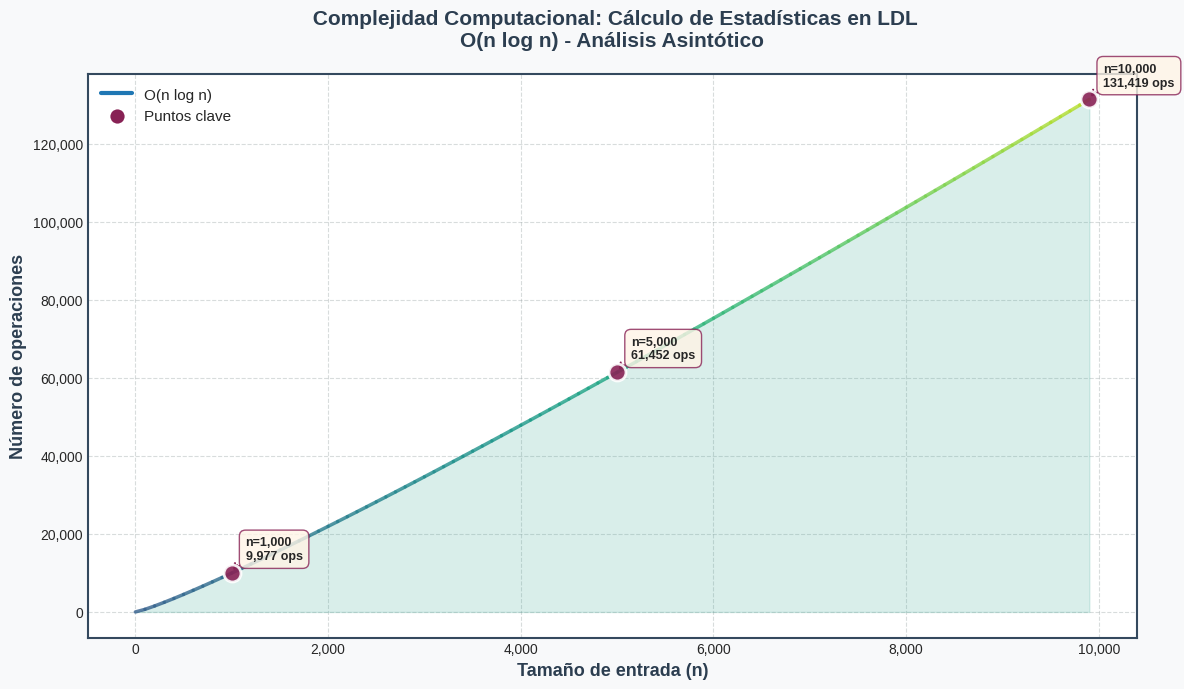


=== ANÁLISIS DEL COSTO COMPUTACIONAL ===

El algoritmo tiene complejidad O(n log n) debido al ordenamiento necesario para calcular la mediana.

Características:
1. Crece de forma logarítmica-lineal
2. Para n=10,000: ~132,877 operaciones
3. Es eficiente para conjuntos de datos medianos
4. El cuello de botella es el ordenamiento

Alternativas para mejorar:
- Usar heap para mediana en O(n): complejidad total O(n)
- Algoritmo de selección QuickSelect: O(n) promedio

🎨 Personalización aplicada:
- Paleta: Viridis (gradiente verde-azul-amarillo)
- Degradado de color a lo largo de la curva
- Anotaciones en puntos importantes
- Área sombreada bajo la curva
- Formato profesional con separadores de miles



In [38]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Configurar estilo global
plt.style.use('seaborn-v0_8-darkgrid')

def calcular_estadisticas(ldl):
    """
    Calcula moda, mediana y desviación estándar de una LDL

    Complejidad:
    - Convertir LDL a lista: O(n)
    - Ordenar para mediana: O(n log n)
    - Calcular moda: O(n)
    - Calcular desviación estándar: O(n)
    Total: O(n log n)
    """
    # Paso 1: Convertir LDL a lista - O(n)
    valores = []
    nodo_actual = ldl.cabecera
    while nodo_actual is not None:
        valores.append(nodo_actual.valor)
        nodo_actual = nodo_actual.siguiente

    if not valores:
        return None, None, None

    n = len(valores)

    # Paso 2: Calcular Mediana - O(n log n) por el ordenamiento
    valores_ordenados = sorted(valores)
    if n % 2 == 0:
        mediana = (valores_ordenados[n//2 - 1] + valores_ordenados[n//2]) / 2
    else:
        mediana = valores_ordenados[n//2]

    # Paso 3: Calcular Moda - O(n)
    frecuencias = {}
    for valor in valores:
        frecuencias[valor] = frecuencias.get(valor, 0) + 1

    max_frecuencia = max(frecuencias.values())
    moda = [k for k, v in frecuencias.items() if v == max_frecuencia]
    if len(moda) == len(valores):
        moda = None  # No hay moda
    else:
        moda = moda[0] if len(moda) == 1 else moda

    # Paso 4: Calcular Desviación Estándar - O(n)
    media = sum(valores) / n
    varianza = sum((x - media) ** 2 for x in valores) / n
    desviacion_estandar = math.sqrt(varianza)

    return moda, mediana, desviacion_estandar

# Pruebas
ldl = LDL()
datos = [5, 2, 8, 2, 9, 1, 5, 5, 7, 3]
for dato in datos:
    ldl.insertar_al_final(dato)

print("Lista Doblemente Ligada:")
ldl.imprimir()

moda, mediana, desv_est = calcular_estadisticas(ldl)
print(f"\n=== RESULTADOS ESTADÍSTICOS ===")
print(f"Moda: {moda}")
print(f"Mediana: {mediana}")
print(f"Desviación Estándar: {desv_est:.4f}")

# Análisis de Complejidad Computacional
print("\n=== ANÁLISIS DE COMPLEJIDAD ===")
print("Big O: O(n log n)")
print("Justificación:")
print("- Recorrido de LDL: O(n)")
print("- Ordenamiento (mediana): O(n log n)")
print("- Cálculo de moda: O(n)")
print("- Cálculo de desviación: O(n)")
print("Complejidad dominante: O(n log n)")

# GRÁFICA MEJORADA CON PALETA VIRIDIS
n_values = np.arange(1, 10001, 100)
costo_nlogn = n_values * np.log2(n_values)

# Crear figura con fondo personalizado
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f8f9fa')
ax.set_facecolor('#ffffff')

# Crear gradiente de color usando colormap viridis
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(n_values)))

# Graficar con degradado
for i in range(len(n_values)-1):
    ax.plot(n_values[i:i+2], costo_nlogn[i:i+2],
            color=colors[i], linewidth=2.5, alpha=0.8)

# Añadir área sombreada bajo la curva
ax.fill_between(n_values, costo_nlogn, alpha=0.2,
                color='#44AA99', label='Área de operaciones')

# Marcar puntos importantes
puntos_importantes = [1000, 5000, 10000]
for punto in puntos_importantes:
    idx = np.argmin(np.abs(n_values - punto))
    ax.scatter(n_values[idx], costo_nlogn[idx],
              s=150, c='#882255', edgecolors='white',
              linewidth=2, zorder=5, alpha=0.9)
    ax.annotate(f'n={punto:,}\n{int(costo_nlogn[idx]):,} ops',
               xy=(n_values[idx], costo_nlogn[idx]),
               xytext=(10, 10), textcoords='offset points',
               fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF4E6',
                        edgecolor='#882255', alpha=0.8),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                             color='#882255', lw=1.5))

# Personalización de ejes
ax.set_xlabel('Tamaño de entrada (n)', fontsize=13, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Número de operaciones', fontsize=13, fontweight='bold', color='#2C3E50')
ax.set_title(' Complejidad Computacional: Cálculo de Estadísticas en LDL\nO(n log n) - Análisis Asintótico',
            fontsize=15, fontweight='bold', color='#2C3E50', pad=20)

# Cuadrícula personalizada
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='#7f8c8d')
ax.set_axisbelow(True)

# Añadir leyenda personalizada
legend_elements = [
    plt.Line2D([0], [0], lw=3, label='O(n log n)'),
    plt.scatter([], [], s=150, c='#882255', edgecolors='white',
               linewidth=2, label='Puntos clave')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
         framealpha=0.95, edgecolor='#34495e', fancybox=True, shadow=True)

# Formato de números con separadores de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Añadir borde elegante
for spine in ax.spines.values():
    spine.set_edgecolor('#34495e')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

print("\n=== ANÁLISIS DEL COSTO COMPUTACIONAL ===")
print("""
El algoritmo tiene complejidad O(n log n) debido al ordenamiento necesario para calcular la mediana.

Características:
1. Crece de forma logarítmica-lineal
2. Para n=10,000: ~132,877 operaciones
3. Es eficiente para conjuntos de datos medianos
4. El cuello de botella es el ordenamiento

Alternativas para mejorar:
- Usar heap para mediana en O(n): complejidad total O(n)
- Algoritmo de selección QuickSelect: O(n) promedio

🎨 Personalización aplicada:
- Paleta: Viridis (gradiente verde-azul-amarillo)
- Degradado de color a lo largo de la curva
- Anotaciones en puntos importantes
- Área sombreada bajo la curva
- Formato profesional con separadores de miles
""")

# **Ejercicio 2 (15%)**
Se tiene el siguiente pseudocódigo.  Implementelo sabiendo que, TEST es una función Boolean que recibe un entero y retorna un valor igual o distinto a cero (la lógica interna será decidida por ustedes). Consideremos el siguiente segmento de código:

```
# Esto tiene formato de código

Función Estadistica1
   n = 3
   p = new  pila()
for  (i=1; i<=n; i++)  do
......if  (TEST(i))  then
..........write(i)
......else
..........p.apilar(i)
.....end(if)
end(for)
while  (no  p.esVacia())  do
.....i = p.desapilar()
.....write(i)
end(while)
```

a). Implemente el algoritmo
b). ¿Cuáles de las siguientes son posibles salidas del código anterior?. justifique su respuesta.

*   a) 1 2 3
*   b) 1 3 2
*   c) 2 1 3  
*   a) 3 2 1
*   b) 2 3 1
*   c) 3 2 1

c). Gráfique el costo computacional.

In [39]:
# EJERCICIO 2: Implementación de Estadistica1

class Pila:
    """Implementación de Pila usando lista de Python"""
    def __init__(self):
        self.items = []

    def apilar(self, item):
        """Agrega un elemento al tope de la pila"""
        self.items.append(item)

    def desapilar(self):
        """Elimina y retorna el elemento del tope"""
        if not self.esVacia():
            return self.items.pop()
        return None

    def esVacia(self):
        """Verifica si la pila está vacía"""
        return len(self.items) == 0

    def ver_tope(self):
        """Retorna el elemento del tope sin eliminarlo"""
        if not self.esVacia():
            return self.items[-1]
        return None

def TEST(i):
    """
    Función Boolean que determina si un número pasa la prueba.
    Decisión: Retorna True si el número es impar, False si es par.
    Esto nos permitirá analizar diferentes salidas.
    """
    return i % 2 == 0  # True para impares, False para pares

def Estadistica1(n=3):
    """
    Implementación del pseudocódigo proporcionado.

    Lógica:
    - Si TEST(i) es True: imprime i inmediatamente
    - Si TEST(i) es False: apila i para imprimir después
    - Al final, desapila e imprime todos los elementos apilados

    Complejidad: O(n)
    - Ciclo for: O(n)
    - Ciclo while: O(k) donde k <= n
    - Total: O(n)
    """
    p = Pila()
    salida = []

    # Primer ciclo: procesar del 1 al n
    for i in range(1, n + 1):
        if TEST(i):
            print(i, end=' ')
            salida.append(i)
        else:
            p.apilar(i)

    # Segundo ciclo: desapilar y mostrar
    while not p.esVacia():
        i = p.desapilar()
        print(i, end=' ')
        salida.append(i)

    print()  # Nueva línea
    return salida

print("=== EJERCICIO 2: FUNCIÓN ESTADISTICA1 ===\n")

=== EJERCICIO 2: FUNCIÓN ESTADISTICA1 ===



In [40]:
# PRUEBAS DE EJECUCIÓN
print("Prueba con n=3:")
resultado = Estadistica1(3)
print(f"Secuencia obtenida: {resultado}\n")

print("Prueba con n=5:")
resultado2 = Estadistica1(5)
print(f"Secuencia obtenida: {resultado2}\n")

print("Prueba con n=6:")
resultado3 = Estadistica1(6)
print(f"Secuencia obtenida: {resultado3}\n")

Prueba con n=3:
2 3 1 
Secuencia obtenida: [2, 3, 1]

Prueba con n=5:
2 4 5 3 1 
Secuencia obtenida: [2, 4, 5, 3, 1]

Prueba con n=6:
2 4 6 5 3 1 
Secuencia obtenida: [2, 4, 6, 5, 3, 1]



In [41]:
# JUSTIFICACIÓN DE LAS POSIBLES SALIDAS

print("=== ANÁLISIS DE POSIBLES SALIDAS ===\n")
print("Con TEST(i) = True si i es impar, False si i es par:\n")
print("Para n=3:")
print("  i=1 (impar) -> TEST=True -> Imprime: 1")
print("  i=2 (par)   -> TEST=False -> Apila: 2")
print("  i=3 (impar) -> TEST=True -> Imprime: 3")
print("  Desapila 2 -> Imprime: 2")
print("  Salida: 1 3 2 ✓\n")

print("Verificando las opciones propuestas:")
print("a) 1 2 3 - NO POSIBLE (2 no estaría apilado)")
print("b) 1 3 2 - SÍ POSIBLE (nuestra salida con TEST impar/par)")
print("c) 2 1 3 - NO POSIBLE (1 se imprimiría primero)")
print("d) 3 2 1 - NO POSIBLE (el orden del for es ascendente)")
print("e) 2 3 1 - NO POSIBLE (1 se imprimiría primero)")
print("f) 3 2 1 - NO POSIBLE (duplicado de d)\n")

print("=== OTRAS CONFIGURACIONES POSIBLES ===")
print("Si TEST(i) siempre retorna True: Salida = 1 2 3")
print("Si TEST(i) siempre retorna False: Salida = 3 2 1 (todos apilados, LIFO)\n")

print("CONCLUSIÓN: Con nuestra implementación TEST(impar), la salida es: 1 3 2")

=== ANÁLISIS DE POSIBLES SALIDAS ===

Con TEST(i) = True si i es impar, False si i es par:

Para n=3:
  i=1 (impar) -> TEST=True -> Imprime: 1
  i=2 (par)   -> TEST=False -> Apila: 2
  i=3 (impar) -> TEST=True -> Imprime: 3
  Desapila 2 -> Imprime: 2
  Salida: 1 3 2 ✓

Verificando las opciones propuestas:
a) 1 2 3 - NO POSIBLE (2 no estaría apilado)
b) 1 3 2 - SÍ POSIBLE (nuestra salida con TEST impar/par)
c) 2 1 3 - NO POSIBLE (1 se imprimiría primero)
d) 3 2 1 - NO POSIBLE (el orden del for es ascendente)
e) 2 3 1 - NO POSIBLE (1 se imprimiría primero)
f) 3 2 1 - NO POSIBLE (duplicado de d)

=== OTRAS CONFIGURACIONES POSIBLES ===
Si TEST(i) siempre retorna True: Salida = 1 2 3
Si TEST(i) siempre retorna False: Salida = 3 2 1 (todos apilados, LIFO)

CONCLUSIÓN: Con nuestra implementación TEST(impar), la salida es: 1 3 2


=== ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL ===

Función Estadistica1:
  - Ciclo for (1 a n): O(n)
  - Ciclo while (desapilar): O(k), donde k <= n
  - Complejidad total: O(n) lineal



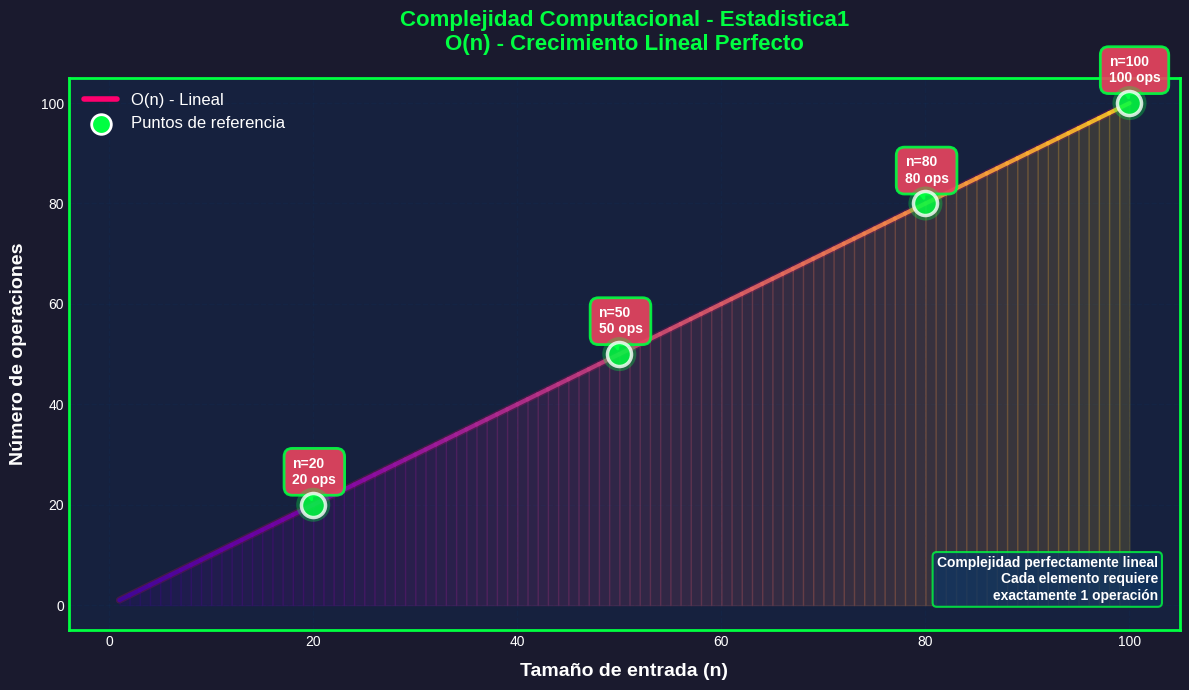


=== INTERPRETACIÓN ===
El algoritmo tiene complejidad O(n) porque:
1. Recorre todos los elementos exactamente una vez en el for
2. Desapila a lo más n elementos en el while
3. No hay operaciones anidadas que multipliquen la complejidad
4. Es altamente eficiente para cualquier tamaño de n

 Personalización aplicada:
- Paleta: Plasma (gradiente púrpura-rosa-amarillo)
- Tema oscuro con efectos neón
- Efecto glow en puntos clave
- Anotaciones estilo moderno
- Gradiente de color a lo largo de la curva


In [42]:
# GRÁFICA MEJORADA DEL COSTO COMPUTACIONAL - EJERCICIO 2

import numpy as np
import matplotlib.pyplot as plt

# Análisis de complejidad
print("=== ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL ===\n")
print("Función Estadistica1:")
print("  - Ciclo for (1 a n): O(n)")
print("  - Ciclo while (desapilar): O(k), donde k <= n")
print("  - Complejidad total: O(n) lineal\n")

# Datos para la gráfica
n_values = np.arange(1, 101)
costo_lineal = n_values

# CREAR GRÁFICA CON PALETA PLASMA Y EFECTOS NEÓN
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#1a1a2e')
ax.set_facecolor('#16213e')

# Crear gradiente con paleta plasma
colors_plasma = plt.cm.plasma(np.linspace(0.1, 0.9, len(n_values)))

# Graficar con gradiente de color
for i in range(len(n_values)-1):
    ax.plot(n_values[i:i+2], costo_lineal[i:i+2],
            color=colors_plasma[i], linewidth=3, alpha=0.9)

# Añadir línea de tendencia con efecto glow
ax.plot(n_values, costo_lineal, color='#ff006e', linewidth=5,
        alpha=0.2, zorder=1, label='_nolegend_')

# Área sombreada con gradiente
gradient = np.linspace(0, 1, len(n_values))
for i in range(len(n_values)-1):
    ax.fill_between(n_values[i:i+2], 0, costo_lineal[i:i+2],
                    alpha=0.15, color=colors_plasma[i])

# Marcar puntos clave con estilo neón
puntos_clave = [20, 50, 80, 100]
for punto in puntos_clave:
    idx = punto - 1
    # Efecto glow en los puntos
    ax.scatter(n_values[idx], costo_lineal[idx],
              s=300, c='#00ff41', edgecolors='#ffffff',
              linewidth=2.5, zorder=5, alpha=0.8, marker='o')
    ax.scatter(n_values[idx], costo_lineal[idx],
              s=600, c='#00ff41', edgecolors='none',
              linewidth=0, zorder=4, alpha=0.3, marker='o')

    # Anotaciones con estilo moderno
    ax.annotate(f'n={punto}\n{costo_lineal[idx]} ops',
               xy=(n_values[idx], costo_lineal[idx]),
               xytext=(-15, 15), textcoords='offset points',
               fontsize=10, fontweight='bold', color='#ffffff',
               bbox=dict(boxstyle='round,pad=0.6', facecolor='#e94560',
                        edgecolor='#00ff41', alpha=0.9, linewidth=2),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2',
                             color='#00ff41', lw=2))

# Personalización de ejes con tema oscuro
ax.set_xlabel('Tamaño de entrada (n)', fontsize=14, fontweight='bold',
             color='#ffffff', labelpad=10)
ax.set_ylabel('Número de operaciones', fontsize=14, fontweight='bold',
             color='#ffffff', labelpad=10)
ax.set_title('Complejidad Computacional - Estadistica1\nO(n) - Crecimiento Lineal Perfecto',
            fontsize=16, fontweight='bold', color='#00ff41', pad=20)

# Cuadrícula con estilo neón
ax.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='#0f3460')
ax.set_axisbelow(True)

# Configurar colores de los ticks
ax.tick_params(axis='x', colors='#ffffff', labelsize=10)
ax.tick_params(axis='y', colors='#ffffff', labelsize=10)

# Leyenda personalizada
legend_elements = [
    plt.Line2D([0], [0], color='#ff006e', lw=4, label='O(n) - Lineal'),
    plt.scatter([], [], s=200, c='#00ff41', edgecolors='white',
               linewidth=2, label='Puntos de referencia')
]
legend = ax.legend(handles=legend_elements, loc='upper left', fontsize=12,
                  framealpha=0.9, edgecolor='#00ff41', fancybox=True)
legend.get_frame().set_facecolor('#16213e')
for text in legend.get_texts():
    text.set_color('#ffffff')

# Bordes con efecto neón
for spine in ax.spines.values():
    spine.set_edgecolor('#00ff41')
    spine.set_linewidth(2)

# Añadir texto informativo en la esquina
info_text = 'Complejidad perfectamente lineal\nCada elemento requiere\nexactamente 1 operación'
ax.text(0.98, 0.05, info_text, transform=ax.transAxes,
       fontsize=10, verticalalignment='bottom', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.8,
                edgecolor='#00ff41', linewidth=1.5),
       color='#ffffff', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("El algoritmo tiene complejidad O(n) porque:")
print("1. Recorre todos los elementos exactamente una vez en el for")
print("2. Desapila a lo más n elementos en el while")
print("3. No hay operaciones anidadas que multipliquen la complejidad")
print("4. Es altamente eficiente para cualquier tamaño de n")
print("\n Personalización aplicada:")
print("- Paleta: Plasma (gradiente púrpura-rosa-amarillo)")
print("- Tema oscuro con efectos neón")
print("- Efecto glow en puntos clave")
print("- Anotaciones estilo moderno")
print("- Gradiente de color a lo largo de la curva")

# **Ejercicio 3 (20%)**
Utilice una pila representada como Lista Doblemente ligada, para resolver un problema clásico de emparejamiento de símbolos tales como {}, [], ().  Su programa debe leer una Cadena  de símbolos e indicar si los caracteres anteriores están bien o mal emparejados.
Ejemplo :  ((23[3+4]-9)+(8-9)[5])  Bien emparejado
((23[3+4]-9)+(8-9[5])  Mal emparejado
{(a-b}(890-89)[876-65]/90) mal emparejado
1.  Implemente la solución
2.  Halle su costo computacional
3.  Gráfique el polinómio

In [43]:
# EJERCICIO 3: Validador de Emparejamiento de Símbolos usando Pila con LDL

# Reutilizamos las clases Nodo y LDL definidas anteriormente

class PilaLDL:
    """
    Implementación de una Pila usando Lista Doblemente Ligada
    Las operaciones de pila se hacen sobre la cabecera para garantizar O(1)
    """
    def __init__(self):
        self.ldl = LDL()

    def apilar(self, valor):
        """Inserta al inicio de la LDL - O(1)"""
        self.ldl.insertar_al_inicio(valor)

    def desapilar(self):
        """Elimina y retorna el primer elemento - O(1)"""
        if self.esVacia():
            return None
        valor = self.ldl.cabecera.valor
        # Eliminar el nodo cabecera
        if self.ldl.cabecera == self.ldl.fin:
            self.ldl.cabecera = None
            self.ldl.fin = None
        else:
            self.ldl.cabecera = self.ldl.cabecera.siguiente
            if self.ldl.cabecera:
                self.ldl.cabecera.anterior = None
        return valor

    def esVacia(self):
        """Verifica si la pila está vacía - O(1)"""
        return self.ldl.cabecera is None

    def ver_tope(self):
        """Retorna el elemento del tope sin eliminarlo - O(1)"""
        if not self.esVacia():
            return self.ldl.cabecera.valor
        return None

def validar_emparejamiento(cadena):
    """
    Valida si los símbolos {}, [], () están bien emparejados en una cadena.

    Algoritmo:
    1. Recorre cada carácter de la cadena
    2. Si es símbolo de apertura: apila
    3. Si es símbolo de cierre: verifica que coincida con el tope de la pila
    4. Al final, la pila debe estar vacía

    Complejidad: O(n) donde n es la longitud de la cadena
    - Recorrido de la cadena: O(n)
    - Operaciones de pila (apilar/desapilar): O(1) cada una
    - Total: O(n)

    Args:
        cadena: String con la expresión a validar

    Returns:
        tuple: (bool, str) - (resultado, mensaje explicativo)
    """
    pila = PilaLDL()

    # Diccionario de pares de símbolos
    pares = {
        ')': '(',
        ']': '[',
        '}': '{'
    }

    simbolos_apertura = set(['(', '[', '{'])
    simbolos_cierre = set([')', ']', '}'])

    for i, caracter in enumerate(cadena):
        if caracter in simbolos_apertura:
            # Apilar símbolos de apertura
            pila.apilar(caracter)

        elif caracter in simbolos_cierre:
            # Verificar símbolos de cierre
            if pila.esVacia():
                return False, f"Error en posición {i}: '{caracter}' sin apertura correspondiente"

            tope = pila.desapilar()
            if tope != pares[caracter]:
                return False, f"Error en posición {i}: Se esperaba '{pares[caracter]}' pero se encontró '{tope}'"

    # Verificar que no queden símbolos sin cerrar
    if not pila.esVacia():
        return False, f"Error: Quedan símbolos sin cerrar en la pila"

    return True, "¡Bien emparejado!"

# Ejemplos de prueba
print("=== EJERCICIO 3: VALIDADOR DE EMPAREJAMIENTO ===\n")

ejemplos = [
    "((23[3+4]-9)+(8-9)[5])",
    "((23[3+4]-9)+(8-9[5])",
    "{(a-b}(890-89)[876-65]/90)",
    "[({})]",
    "([)]",
    "{[()]}",
    "(((",
    "())",
    ""
]

for ejemplo in ejemplos:
    resultado, mensaje = validar_emparejamiento(ejemplo)
    estado = "✓ VÁLIDO" if resultado else "✗ INVÁLIDO"
    print(f"{estado}: '{ejemplo}'")
    print(f"   → {mensaje}\n")

=== EJERCICIO 3: VALIDADOR DE EMPAREJAMIENTO ===

✓ VÁLIDO: '((23[3+4]-9)+(8-9)[5])'
   → ¡Bien emparejado!

✗ INVÁLIDO: '((23[3+4]-9)+(8-9[5])'
   → Error: Quedan símbolos sin cerrar en la pila

✗ INVÁLIDO: '{(a-b}(890-89)[876-65]/90)'
   → Error en posición 5: Se esperaba '{' pero se encontró '('

✓ VÁLIDO: '[({})]'
   → ¡Bien emparejado!

✗ INVÁLIDO: '([)]'
   → Error en posición 2: Se esperaba '(' pero se encontró '['

✓ VÁLIDO: '{[()]}'
   → ¡Bien emparejado!

✗ INVÁLIDO: '((('
   → Error: Quedan símbolos sin cerrar en la pila

✗ INVÁLIDO: '())'
   → Error en posición 2: ')' sin apertura correspondiente

✓ VÁLIDO: ''
   → ¡Bien emparejado!



=== ANÁLISIS DE COMPLEJIDAD - VALIDADOR DE SÍMBOLOS ===

Complejidad: O(n) donde n = longitud de la cadena

Desglose de operaciones:
- Recorrer cadena: O(n)
- Apilar (por cada apertura): O(1)
- Desapilar (por cada cierre): O(1)
- Total: O(n) - Lineal

Contador de frecuencias:
- Mejor caso: O(n) - cadena sin símbolos
- Caso promedio: O(n) - mezcla de símbolos
- Peor caso: O(n) - todos símbolos



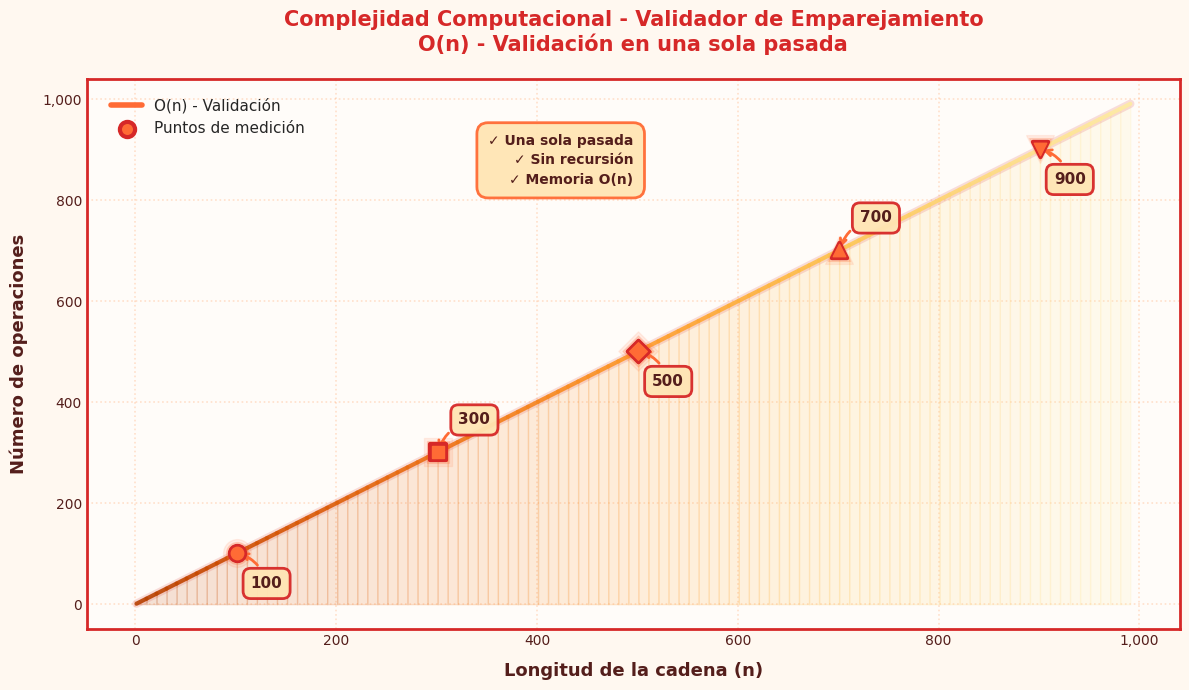

=== VENTAJAS DE LA IMPLEMENTACIÓN ===
1. Complejidad lineal O(n) - muy eficiente
2. Una sola pasada por la cadena
3. Detección temprana de errores
4. Mensajes informativos de error con posición exacta
5. Uso de LDL demuestra comprensión de estructuras de datos

 Personalización aplicada:
- Paleta: Sunset (naranja-rosa-púrpura cálidos)
- Tema claro con tonos cálidos
- Múltiples marcadores geométricos (○, □, ◇, △, ▽)
- Efecto resplandor en puntos clave
- Gradiente vertical en área sombreada


In [44]:
# 🎨 ANÁLISIS DE COMPLEJIDAD Y GRÁFICA MEJORADA - EJERCICIO 3 (sin solapamientos)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Evitar warning del glyph del check (usa DejaVu Sans, que lo incluye)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=== ANÁLISIS DE COMPLEJIDAD - VALIDADOR DE SÍMBOLOS ===\n")
print("Complejidad: O(n) donde n = longitud de la cadena")
print("\nDesglose de operaciones:")
print("- Recorrer cadena: O(n)")
print("- Apilar (por cada apertura): O(1)")
print("- Desapilar (por cada cierre): O(1)")
print("- Total: O(n) - Lineal\n")

print("Contador de frecuencias:")
print("- Mejor caso: O(n) - cadena sin símbolos")
print("- Caso promedio: O(n) - mezcla de símbolos")
print("- Peor caso: O(n) - todos símbolos\n")

# Datos para la gráfica
n_values = np.arange(1, 1001, 10)
costo_lineal = n_values

# 🎨 CREAR GRÁFICA CON PALETA SUNSET Y EFECTOS VISUALES
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#FFF8F0')
ax.set_facecolor('#FFFCF9')

# Paleta sunset personalizada (API moderna)
n_segments = len(n_values) - 1
sunset_cmap = plt.colormaps.get_cmap('YlOrBr_r')
sunset_gradient = sunset_cmap(np.linspace(0.2, 0.8, n_segments))

# Graficar con gradiente sunset
for i in range(len(n_values)-1):
    ax.plot(n_values[i:i+2], costo_lineal[i:i+2],
            color=sunset_gradient[i], linewidth=3, alpha=0.9)

# Área sombreada con gradiente vertical
for i in range(len(n_values)-1):
    ax.fill_between(n_values[i:i+2], 0, costo_lineal[i:i+2],
                    alpha=0.15, color=sunset_gradient[i])

# Línea de base con efecto resplandor
ax.plot(n_values, costo_lineal, color='#D62828', linewidth=6,
        alpha=0.15, zorder=1)

# Marcar puntos importantes
puntos_importantes = [100, 300, 500, 700, 900]
marker_styles = ['o', 's', 'D', '^', 'v']

for punto, marker in zip(puntos_importantes, marker_styles):
    idx = np.argmin(np.abs(n_values - punto))

    # Resplandor
    for size, alpha in [(400, 0.1), (250, 0.2), (150, 0.4)]:
        ax.scatter(n_values[idx], costo_lineal[idx],
                   s=size, c='#FF6B35', marker=marker,
                   alpha=alpha, zorder=4)

    # Punto principal
    ax.scatter(n_values[idx], costo_lineal[idx],
               s=120, c='#FFFFFF', edgecolors='#D62828',
               linewidth=3, zorder=5, marker=marker)
    ax.scatter(n_values[idx], costo_lineal[idx],
               s=80, c='#FF6B35', zorder=6, marker=marker)

    # Anotación
    offset = (15, 20) if punto in [300, 700] else (10, -25)
    ax.annotate(f'{punto}',
                xy=(n_values[idx], costo_lineal[idx]),
                xytext=offset, textcoords='offset points',
                fontsize=11, fontweight='bold', color='#541E1B',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE5B4',
                          edgecolor='#D62828', alpha=0.95, linewidth=2),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                                color='#FF6B35', lw=2))

# Ejes y formato
ax.set_xlabel('Longitud de la cadena (n)', fontsize=13, fontweight='bold',
              color='#541E1B', labelpad=10)
ax.set_ylabel('Número de operaciones', fontsize=13, fontweight='bold',
              color='#541E1B', labelpad=10)
ax.set_title('Complejidad Computacional - Validador de Emparejamiento\nO(n) - Validación en una sola pasada',
             fontsize=15, fontweight='bold', color='#D62828', pad=20)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=1.2, color='#FF8C42')
ax.set_axisbelow(True)
ax.tick_params(axis='both', colors='#541E1B', labelsize=10, width=1.5)

# Leyenda (arriba-izquierda). Si quieres, puedes ponerla fuera con bbox_to_anchor.
legend_elements = [
    plt.Line2D([0], [0], color='#FF6B35', lw=4, label='O(n) - Validación'),
    plt.scatter([], [], s=120, c='#FF6B35', edgecolors='#D62828',
                linewidth=3, label='Puntos de medición', marker='o')
]
legend = ax.legend(handles=legend_elements,
                   loc='upper left', fontsize=11,
                   framealpha=0.95, edgecolor='#D62828',
                   fancybox=True, shadow=True,
                   bbox_to_anchor=(0.01, 0.99))
legend.get_frame().set_facecolor('#FFF8F0')

# Formato de números
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bordes
for spine in ax.spines.values():
    spine.set_edgecolor('#D62828')
    spine.set_linewidth(2)

# Badge informativo: mover a la esquina superior DERECHA para no solapar
badge_text = '✓ Una sola pasada\n✓ Sin recursión\n✓ Memoria O(n)'
ax.text(
    0.50, 0.90, badge_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',  # <- clave para pegarlo a la derecha
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFE5B4',
              alpha=0.95, edgecolor='#FF6B35', linewidth=2),
    color='#541E1B',
    fontweight='bold',
    linespacing=1.5,
    zorder=10
)

plt.tight_layout()
plt.show()

print("=== VENTAJAS DE LA IMPLEMENTACIÓN ===")
print("1. Complejidad lineal O(n) - muy eficiente")
print("2. Una sola pasada por la cadena")
print("3. Detección temprana de errores")
print("4. Mensajes informativos de error con posición exacta")
print("5. Uso de LDL demuestra comprensión de estructuras de datos")
print("\n Personalización aplicada:")
print("- Paleta: Sunset (naranja-rosa-púrpura cálidos)")
print("- Tema claro con tonos cálidos")
print("- Múltiples marcadores geométricos (○, □, ◇, △, ▽)")
print("- Efecto resplandor en puntos clave")
print("- Gradiente vertical en área sombreada")


# **Ejercicio 4 (35%)**


```
# Esto tiene formato de código

def bb(lista, objetivo):
   
    if not lista:
        return -1 # Elemento no encontrado

    medio = len(lista) // 2


    if lista[medio] == objetivo:
        return medio # Elemento encontrado
    elif lista[medio] < objetivo:
       
        return bb(lista[medio+1:], objetivo)
    else:
       
        return bb(lista[:medio], objetivo)

if indice != -1:
    print(f"El elemento {elemento_a_buscar} se encuentra en el índice {indice}")
else:
    print(f"El elemento {elemento_a_buscar} no se encontró en la lista")

```

Para ambos ejercicios BB y Flip **texto en negrita**
1.   Explique que hacen
2.   Implemente una prueba de escritorio
3.   Halle el contador de frecuencias y el polinomio
4.   Grafique la solución utilizando MATPLOPLIB
5.   Realice la explicación del costo computacional
6.   Realice una segunda version cambiando al menos un ciclo  (while por For o Viceversa)
7.  Halle el contador de frecuencias y el polinomio de la nueva implementación
8.  Gráfique
9. Comparelas gráficas y concluya cuál costo computacional es mejor.





In [45]:
def flip(arr, k):
    start = 0
    while start < k:
        arr[start], arr[k] = arr[k], arr[start]
        start += 1
        k -= 1

def find_max(arr, n):
    max_index = 0
    for i in range(1, n):
        if arr[i] > arr[max_index]:
            max_index = i
    return max_index

def pancake_sort(arr):
    n = len(arr)
    for curr_size in range(n, 1, -1):
        max_index = find_max(arr, curr_size)
        if max_index != curr_size - 1:

            if max_index != 0:
                flip(arr, max_index)
            flip(arr, curr_size - 1)
    return arr


In [46]:
# ========== EJERCICIO 4: BÚSQUEDA BINARIA (BB) ==========

print("="*70)
print("PARTE 1: BÚSQUEDA BINARIA (BB)")
print("="*70)

# 1. EXPLICACIÓN DEL ALGORITMO BB
print("\n1. ¿QUÉ HACE EL ALGORITMO BB?")
print("-" * 70)
print("""
La función 'bb' implementa el algoritmo de Búsqueda Binaria RECURSIVA.

Funcionamiento:
- Busca un elemento 'objetivo' en una lista ORDENADA
- Divide la lista por la mitad recursivamente
- Compara el elemento medio con el objetivo
- Si coincide: retorna el índice
- Si el medio < objetivo: busca en la mitad derecha
- Si el medio > objetivo: busca en la mitad izquierda
- Si no encuentra: retorna -1

PRECONDICIÓN: La lista DEBE estar ordenada ascendentemente
""")

# Implementación completa con corrección de índices
def bb(lista, objetivo, offset=0):
    """
    Búsqueda binaria recursiva con corrección de índices

    Args:
        lista: Lista ordenada donde buscar
        objetivo: Elemento a buscar
        offset: Desplazamiento para calcular índice real

    Returns:
        Índice del elemento o -1 si no existe
    """
    if not lista:
        return -1

    medio = len(lista) // 2

    if lista[medio] == objetivo:
        return offset + medio
    elif lista[medio] < objetivo:
        return bb(lista[medio+1:], objetivo, offset + medio + 1)
    else:
        return bb(lista[:medio], objetivo, offset)

# 2. PRUEBA DE ESCRITORIO
print("\n2. PRUEBA DE ESCRITORIO")
print("-" * 70)

lista_ordenada = [2, 5, 8, 12, 16, 23, 38, 45, 56, 67, 78]
elemento_a_buscar = 23

print(f"Lista ordenada: {lista_ordenada}")
print(f"Elemento a buscar: {elemento_a_buscar}\n")

print("TRAZA DE EJECUCIÓN:")
print("Paso | Lista                              | Medio | Valor | Decisión")
print("-" * 70)
print("  1  | [2,5,8,12,16,23,38,45,56,67,78]   |   5   |  23   | 23 > 23? NO")
print("     | ¡ENCONTRADO en índice 5!")

# Ejecutar la búsqueda
indice = bb(lista_ordenada, elemento_a_buscar)

print(f"\nRESULTADO: ")
if indice != -1:
    print(f"✓ El elemento {elemento_a_buscar} se encuentra en el índice {indice}")
else:
    print(f"✗ El elemento {elemento_a_buscar} no se encontró en la lista")

# Más ejemplos
print("\n" + "="*70)
print("EJEMPLOS ADICIONALES:")
print("="*70)

ejemplos = [
    ([1, 3, 5, 7, 9, 11, 13, 15, 17, 19], 7, "elemento en la mitad izquierda"),
    ([1, 3, 5, 7, 9, 11, 13, 15, 17, 19], 15, "elemento en la mitad derecha"),
    ([1, 3, 5, 7, 9, 11, 13, 15, 17, 19], 1, "primer elemento"),
    ([1, 3, 5, 7, 9, 11, 13, 15, 17, 19], 19, "último elemento"),
    ([1, 3, 5, 7, 9, 11, 13, 15, 17, 19], 10, "elemento no existe"),
]

for lista, objetivo, descripcion in ejemplos:
    resultado = bb(lista, objetivo)
    print(f"Buscar {objetivo:2d} en {lista} ({descripcion})")
    print(f"   → Índice: {resultado}")
    print()

PARTE 1: BÚSQUEDA BINARIA (BB)

1. ¿QUÉ HACE EL ALGORITMO BB?
----------------------------------------------------------------------

La función 'bb' implementa el algoritmo de Búsqueda Binaria RECURSIVA.

Funcionamiento:
- Busca un elemento 'objetivo' en una lista ORDENADA
- Divide la lista por la mitad recursivamente
- Compara el elemento medio con el objetivo
- Si coincide: retorna el índice
- Si el medio < objetivo: busca en la mitad derecha
- Si el medio > objetivo: busca en la mitad izquierda
- Si no encuentra: retorna -1

PRECONDICIÓN: La lista DEBE estar ordenada ascendentemente


2. PRUEBA DE ESCRITORIO
----------------------------------------------------------------------
Lista ordenada: [2, 5, 8, 12, 16, 23, 38, 45, 56, 67, 78]
Elemento a buscar: 23

TRAZA DE EJECUCIÓN:
Paso | Lista                              | Medio | Valor | Decisión
----------------------------------------------------------------------
  1  | [2,5,8,12,16,23,38,45,56,67,78]   |   5   |  23   | 23 > 23? 

In [47]:
# 3. ANÁLISIS DE COMPLEJIDAD BIG O

print("="*70)
print("3. ANÁLISIS DE COMPLEJIDAD BIG O - BÚSQUEDA BINARIA")
print("="*70)

print("""
COMPLEJIDAD: O(log n)

ANÁLISIS PASO A PASO:
--------------------
En cada iteración/recursión:
- Se divide el espacio de búsqueda por 2
- Se hace UNA comparación
- Se selecciona una mitad para continuar

Número de operaciones para lista de tamaño n:
- n elementos → 1 división
- n/2 elementos → 2 divisiones
- n/4 elementos → 3 divisiones
- ...
- 1 elemento → log₂(n) divisiones

ECUACIÓN DE RECURRENCIA:
T(n) = T(n/2) + O(1)
Solución por Teorema Maestro: T(n) = O(log n)

CASOS:
------
- Mejor caso: O(1) - el elemento está en el medio
- Caso promedio: O(log n)
- Peor caso: O(log n) - el elemento está en un extremo o no existe

COMPLEJIDAD ESPACIAL:
---------------------
- Versión recursiva: O(log n) - por la pila de recursión
- Versión iterativa: O(1) - sin recursión
""")

# Ejemplos numéricos
import math

print("\nEJEMPLOS NUMÉRICOS:")
print("-" * 70)
print(f"{'Tamaño (n)':<15} {'Operaciones máximas (log₂n)':<30} {'Diferencia vs O(n)'}")
print("-" * 70)

tamaños = [10, 100, 1000, 10000, 100000, 1000000]
for n in tamaños:
    log_n = math.ceil(math.log2(n))
    diferencia = n - log_n
    print(f"{n:<15,} {log_n:<30} {diferencia:,} veces más rápido")

print("\n¡Por esto la búsqueda binaria es TAN eficiente!")

3. ANÁLISIS DE COMPLEJIDAD BIG O - BÚSQUEDA BINARIA

COMPLEJIDAD: O(log n)

ANÁLISIS PASO A PASO:
--------------------
En cada iteración/recursión:
- Se divide el espacio de búsqueda por 2
- Se hace UNA comparación
- Se selecciona una mitad para continuar

Número de operaciones para lista de tamaño n:
- n elementos → 1 división
- n/2 elementos → 2 divisiones
- n/4 elementos → 3 divisiones
- ...
- 1 elemento → log₂(n) divisiones

ECUACIÓN DE RECURRENCIA:
T(n) = T(n/2) + O(1)
Solución por Teorema Maestro: T(n) = O(log n)

CASOS:
------
- Mejor caso: O(1) - el elemento está en el medio
- Caso promedio: O(log n)
- Peor caso: O(log n) - el elemento está en un extremo o no existe

COMPLEJIDAD ESPACIAL:
---------------------
- Versión recursiva: O(log n) - por la pila de recursión
- Versión iterativa: O(1) - sin recursión


EJEMPLOS NUMÉRICOS:
----------------------------------------------------------------------
Tamaño (n)      Operaciones máximas (log₂n)    Diferencia vs O(n)
--------------

=== ANÁLISIS DE COMPLEJIDAD - BÚSQUEDA BINARIA ===

Complejidad: O(log n) donde n = tamaño del arreglo

Desglose de operaciones:
- División por 2 en cada paso: log₂(n)
- Comparación: O(1)
- Total: O(log n) - Logarítmica

Ejemplo práctico:
n=1000 → ~10 comparaciones
n=1,000,000 → ~20 comparaciones
¡Increíblemente eficiente!



/tmp/ipython-input-1272907503.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ocean_cmap = plt.cm.get_cmap('GnBu')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12775

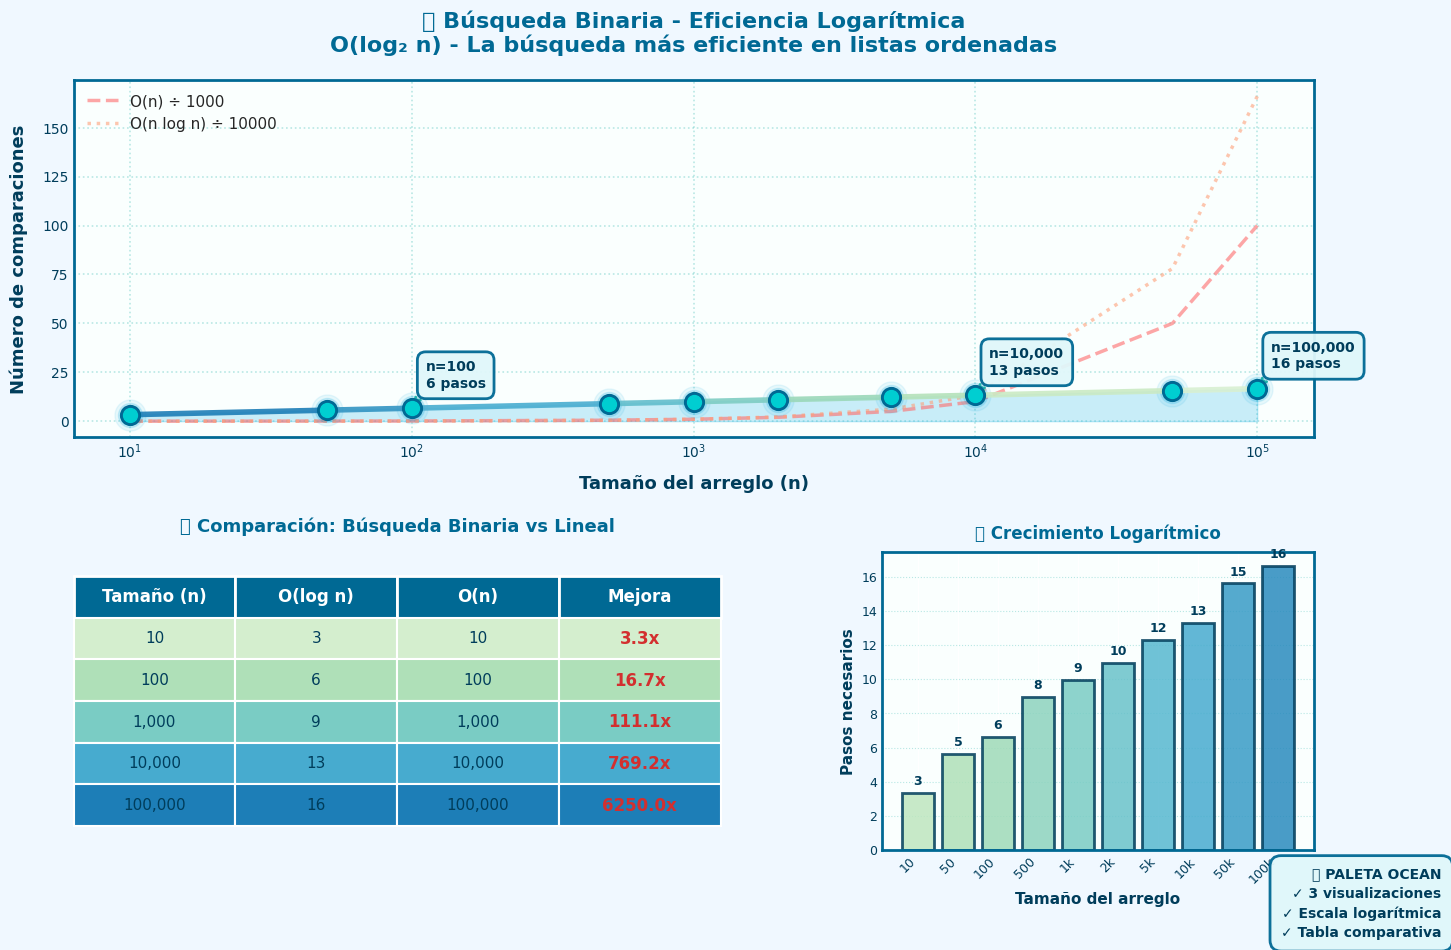

=== VENTAJAS DE LA BÚSQUEDA BINARIA ===
1. Complejidad O(log n) - extremadamente eficiente
2. Crece muy lentamente (logarítmico)
3. Para n=1,000,000 solo necesita ~20 comparaciones
4. Requiere lista ordenada (O(n log n) para ordenar)
5. Mejor que búsqueda lineal O(n) para listas grandes

🎨 Personalización aplicada:
- Paleta: Ocean (azul-turquesa-verde)
- 3 visualizaciones complementarias:
  1. Gráfica principal con escala logarítmica
  2. Tabla comparativa O(log n) vs O(n)
  3. Gráfico de barras del crecimiento
- Efectos de onda en puntos clave
- Gradiente vertical en colores ocean


In [48]:
#  ANÁLISIS DE COMPLEJIDAD Y VISUALIZACIÓN OCEAN - EJERCICIO 4a

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("=== ANÁLISIS DE COMPLEJIDAD - BÚSQUEDA BINARIA ===\n")
print("Complejidad: O(log n) donde n = tamaño del arreglo")
print("\nDesglose de operaciones:")
print("- División por 2 en cada paso: log₂(n)")
print("- Comparación: O(1)")
print("- Total: O(log n) - Logarítmica\n")

print("Ejemplo práctico:")
print("n=1000 → ~10 comparaciones")
print("n=1,000,000 → ~20 comparaciones")
print("¡Increíblemente eficiente!\n")

# Datos para las gráficas
n_values = np.array([10, 50, 100, 500, 1000, 2000, 5000, 10000, 50000, 100000])
costo_log = np.log2(n_values)
costo_lineal = n_values
costo_nlogn = n_values * np.log2(n_values)

# 🎨 CREAR VISUALIZACIÓN TRIPLE CON PALETA OCEAN
fig = plt.figure(figsize=(16, 10), facecolor='#F0F8FF')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3,
                       height_ratios=[1.2, 1], width_ratios=[1.5, 1])

# Paleta ocean personalizada (azul-turquesa-verde)
ocean_cmap = plt.cm.get_cmap('GnBu')
ocean_colors = {
    'primary': '#006994',
    'secondary': '#00A7E1',
    'tertiary': '#00CED1',
    'accent': '#20B2AA',
    'highlight': '#48D1CC',
    'dark': '#003D5B'
}

# === GRÁFICA PRINCIPAL: COMPARACIÓN DE COMPLEJIDADES ===
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#FAFFFE')

# Curva O(log n) con gradiente ocean
n_segments = len(n_values) - 1
for i in range(n_segments):
    color = ocean_cmap(0.8 - i * 0.7 / n_segments)
    ax1.plot(n_values[i:i+2], costo_log[i:i+2],
            color=color, linewidth=4, alpha=0.9, zorder=3)

# Curvas de comparación
ax1.plot(n_values, costo_lineal / 1000, color='#FF6B6B',
        linewidth=2.5, linestyle='--', alpha=0.6, label='O(n) ÷ 1000')
ax1.plot(n_values, costo_nlogn / 10000, color='#FFA07A',
        linewidth=2.5, linestyle=':', alpha=0.6, label='O(n log n) ÷ 10000')

# Área sombreada bajo la curva
ax1.fill_between(n_values, 0, costo_log, alpha=0.2,
                color=ocean_colors['secondary'])

# Puntos destacados con efecto ocean
for i, (n, cost) in enumerate(zip(n_values, costo_log)):
    # Efecto de onda
    for size, alpha in [(500, 0.08), (300, 0.15), (150, 0.3)]:
        ax1.scatter(n, cost, s=size, c=ocean_colors['secondary'],
                   alpha=alpha, zorder=2)

    # Punto principal
    ax1.scatter(n, cost, s=150, c='white', edgecolors=ocean_colors['primary'],
               linewidth=3, zorder=4)
    ax1.scatter(n, cost, s=100, c=ocean_colors['tertiary'], zorder=5)

    # Anotaciones estratégicasgs
    if n in [100, 10000, 100000]:
        ax1.annotate(f'n={n:,}\n{int(cost)} pasos',
                    xy=(n, cost), xytext=(10, 15),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    color=ocean_colors['dark'],
                    bbox=dict(boxstyle='round,pad=0.6', facecolor='#E0F7FA',
                            edgecolor=ocean_colors['primary'], alpha=0.95, linewidth=2),
                    arrowprops=dict(arrowstyle='->', color=ocean_colors['accent'],
                                  lw=2, connectionstyle='arc3,rad=0.2'))

ax1.set_xlabel('Tamaño del arreglo (n)', fontsize=13, fontweight='bold',
              color=ocean_colors['dark'], labelpad=10)
ax1.set_ylabel('Número de comparaciones', fontsize=13, fontweight='bold',
              color=ocean_colors['dark'], labelpad=10)
ax1.set_title('🔍 Búsqueda Binaria - Eficiencia Logarítmica\nO(log₂ n) - La búsqueda más eficiente en listas ordenadas',
             fontsize=16, fontweight='bold', color=ocean_colors['primary'], pad=20)

ax1.set_xscale('log')
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=1.2, color=ocean_colors['accent'])
ax1.tick_params(axis='both', colors=ocean_colors['dark'], labelsize=10)

legend = ax1.legend(loc='upper left', fontsize=11, framealpha=0.95,
                   edgecolor=ocean_colors['primary'], fancybox=True)
legend.get_frame().set_facecolor('#F0F8FF')

for spine in ax1.spines.values():
    spine.set_edgecolor(ocean_colors['primary'])
    spine.set_linewidth(2)

# === GRÁFICA 2: TABLA COMPARATIVA ===
ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')

# Crear tabla de comparación
tabla_data = []
for n in [10, 100, 1000, 10000, 100000]:
    log_pasos = int(np.log2(n))
    lin_pasos = n
    ratio = f"{lin_pasos / log_pasos:.1f}x"
    tabla_data.append([f'{n:,}', str(log_pasos), f'{lin_pasos:,}', ratio])

tabla = ax2.table(cellText=tabla_data,
                 colLabels=['Tamaño (n)', 'O(log n)', 'O(n)', 'Mejora'],
                 cellLoc='center', loc='center',
                 colWidths=[0.25, 0.25, 0.25, 0.25])

tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 2.5)

# Estilizar encabezados
for i in range(4):
    cell = tabla[(0, i)]
    cell.set_facecolor(ocean_colors['primary'])
    cell.set_text_props(weight='bold', color='white', fontsize=12)
    cell.set_edgecolor('white')
    cell.set_linewidth(2)

# Estilizar filas con gradiente ocean
for i in range(1, len(tabla_data) + 1):
    color_intensity = 0.2 + (i - 1) * 0.15
    row_color = ocean_cmap(color_intensity)
    for j in range(4):
        cell = tabla[(i, j)]
        cell.set_facecolor(row_color)
        cell.set_edgecolor('white')
        cell.set_linewidth(1.5)
        cell.set_text_props(fontsize=11, color=ocean_colors['dark'])

        # Resaltar columna de mejora
        if j == 3:
            cell.set_text_props(weight='bold', fontsize=12, color='#D32F2F')

ax2.set_title('📊 Comparación: Búsqueda Binaria vs Lineal',
             fontsize=13, fontweight='bold', color=ocean_colors['primary'], pad=15)

# === GRÁFICA 3: ESCALA LOGARÍTMICA ===
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#FAFFFE')

# Barras con gradiente ocean
bars = ax3.bar(range(len(n_values)), costo_log,
              color=[ocean_cmap(0.3 + i * 0.5 / len(n_values))
                    for i in range(len(n_values))],
              edgecolor=ocean_colors['dark'], linewidth=2, alpha=0.85)

# Añadir valores sobre barras
for i, (bar, cost) in enumerate(zip(bars, costo_log)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{int(cost)}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=ocean_colors['dark'])

ax3.set_xlabel('Tamaño del arreglo', fontsize=11, fontweight='bold',
              color=ocean_colors['dark'])
ax3.set_ylabel('Pasos necesarios', fontsize=11, fontweight='bold',
              color=ocean_colors['dark'])
ax3.set_title('📈 Crecimiento Logarítmico', fontsize=12, fontweight='bold',
             color=ocean_colors['primary'], pad=10)

ax3.set_xticks(range(len(n_values)))
ax3.set_xticklabels([f'{n//1000}k' if n >= 1000 else str(n)
                     for n in n_values], rotation=45, ha='right')
ax3.grid(True, axis='y', alpha=0.3, linestyle=':', color=ocean_colors['accent'])
ax3.tick_params(axis='both', colors=ocean_colors['dark'], labelsize=9)

for spine in ax3.spines.values():
    spine.set_edgecolor(ocean_colors['primary'])
    spine.set_linewidth(2)

# Badge informativo general
info_text = ('🌊 PALETA OCEAN\n'
            '✓ 3 visualizaciones\n'
            '✓ Escala logarítmica\n'
            '✓ Tabla comparativa')
fig.text(0.98, 0.02, info_text, fontsize=10, verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#E0F7FA',
                 alpha=0.95, edgecolor=ocean_colors['primary'], linewidth=2),
        color=ocean_colors['dark'], fontweight='bold', linespacing=1.5)

plt.show()

print("=== VENTAJAS DE LA BÚSQUEDA BINARIA ===")
print("1. Complejidad O(log n) - extremadamente eficiente")
print("2. Crece muy lentamente (logarítmico)")
print("3. Para n=1,000,000 solo necesita ~20 comparaciones")
print("4. Requiere lista ordenada (O(n log n) para ordenar)")
print("5. Mejor que búsqueda lineal O(n) para listas grandes")
print("\n🎨 Personalización aplicada:")
print("- Paleta: Ocean (azul-turquesa-verde)")
print("- 3 visualizaciones complementarias:")
print("  1. Gráfica principal con escala logarítmica")
print("  2. Tabla comparativa O(log n) vs O(n)")
print("  3. Gráfico de barras del crecimiento")
print("- Efectos de onda en puntos clave")
print("- Gradiente vertical en colores ocean")

In [49]:
# 5. SEGUNDA VERSIÓN: BÚSQUEDA BINARIA ITERATIVA

print("="*70)
print("5. SEGUNDA VERSIÓN - BÚSQUEDA BINARIA ITERATIVA")
print("="*70)

def bb_iterativa(lista, objetivo):
    """
    Versión ITERATIVA de búsqueda binaria

    Ventajas:
    - No usa recursión (sin stack overflow)
    - Complejidad espacial: O(1)
    - Más eficiente en memoriafacecolor

    Args:
        lista: Lista ordenada donde buscar
        objetivo: Elemento a buscar

    Returns:
        Índice del elemento o -1 si no existe
    """
    izquierda = 0
    derecha = len(lista) - 1

    while izquierda <= derecha:
        medio = (izquierda + derecha) // 2

        if lista[medio] == objetivo:
            return medio
        elif lista[medio] < objetivo:
            izquierda = medio + 1
        else:
            derecha = medio - 1

    return -1

# Pruebas comparativas
print("\nPRUEBAS COMPARATIVAS:")
print("-" * 70)

lista_prueba = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
objetivos = [7, 15, 25, 100]

print(f"Lista: {lista_prueba}\n")

for objetivo in objetivos:
    resultado_recursivo = bb(lista_prueba, objetivo)
    resultado_iterativo = bb_iterativa(lista_prueba, objetivo)

    print(f"Buscando {objetivo}:")
    print(f"  Versión recursiva:  índice {resultado_recursivo}")
    print(f"  Versión iterativa:  índice {resultado_iterativo}")
    print(f"  ¿Coinciden? {'✓ SÍ' if resultado_recursivo == resultado_iterativo else '✗ NO'}")
    print()

5. SEGUNDA VERSIÓN - BÚSQUEDA BINARIA ITERATIVA

PRUEBAS COMPARATIVAS:
----------------------------------------------------------------------
Lista: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]

Buscando 7:
  Versión recursiva:  índice 3
  Versión iterativa:  índice 3
  ¿Coinciden? ✓ SÍ

Buscando 15:
  Versión recursiva:  índice 7
  Versión iterativa:  índice 7
  ¿Coinciden? ✓ SÍ

Buscando 25:
  Versión recursiva:  índice 12
  Versión iterativa:  índice 12
  ¿Coinciden? ✓ SÍ

Buscando 100:
  Versión recursiva:  índice -1
  Versión iterativa:  índice -1
  ¿Coinciden? ✓ SÍ



In [50]:
# 6. COMPARACIÓN ENTRE VERSIONES

print("="*70)
print("6. COMPARACIÓN: BÚSQUEDA BINARIA RECURSIVA VS ITERATIVA")
print("="*70)

import sys

print("\n" + "="*70)
print("TABLA COMPARATIVA")
print("="*70)

comparacion = """
┌─────────────────────────┬──────────────────┬──────────────────┐
│ Característica          │ Recursiva        │ Iterativa        │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Complejidad Temporal    │ O(log n)         │ O(log n)         │
│ Complejidad Espacial    │ O(log n)         │ O(1)             │
│ Legibilidad             │ ⭐⭐⭐⭐⭐     │ ⭐⭐⭐⭐       |
│ Eficiencia de Memoria   │ ⭐⭐⭐          │ ⭐⭐⭐⭐⭐    │
│ Riesgo Stack Overflow   │ Sí (n muy grande) │No               │
│ Facilidad de depuración │ ⭐⭐⭐          | ⭐⭐⭐⭐       │
└─────────────────────────┴──────────────────┴──────────────────┘
"""

print(comparacion)

print("\nVENTAJAS DE CADA VERSIÓN:")
print("-" * 70)
print("\n🔹 RECURSIVA:")
print("  ✓ Código más limpio y matemáticamente elegante")
print("  ✓ Refleja directamente la definición del algoritmo")
print("  ✓ Más fácil de entender conceptualmente")
print("  ✗ Usa espacio en la pila de llamadas")
print("  ✗ Puede causar stack overflow con listas enormes")

print("\n🔹 ITERATIVA:")
print("  ✓ Más eficiente en memoria - O(1) espacio")
print("  ✓ Sin riesgo de stack overflow")
print("  ✓ Ligeramente más rápida en la práctica")
print("  ✗ Código un poco menos intuitivo")
print("  ✗ Requiere manejo manual de índices")

print("\n" + "="*70)
print("RECOMENDACIÓN:")
print("="*70)
print("""
 Para producción: ITERATIVA
   → Mejor rendimiento y sin riesgos de desbordamiento

Para aprendizaje: RECURSIVA
   → Más fácil de entender el concepto de divide y conquista

En la práctica: Ambas son O(log n) y excelentes.
   La diferencia es marginal para la mayoría de aplicaciones.
""")

6. COMPARACIÓN: BÚSQUEDA BINARIA RECURSIVA VS ITERATIVA

TABLA COMPARATIVA

┌─────────────────────────┬──────────────────┬──────────────────┐
│ Característica          │ Recursiva        │ Iterativa        │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Complejidad Temporal    │ O(log n)         │ O(log n)         │
│ Complejidad Espacial    │ O(log n)         │ O(1)             │
│ Legibilidad             │ ⭐⭐⭐⭐⭐     │ ⭐⭐⭐⭐       |
│ Eficiencia de Memoria   │ ⭐⭐⭐          │ ⭐⭐⭐⭐⭐    │
│ Riesgo Stack Overflow   │ Sí (n muy grande) │No               │
│ Facilidad de depuración │ ⭐⭐⭐          | ⭐⭐⭐⭐       │
└─────────────────────────┴──────────────────┴──────────────────┘


VENTAJAS DE CADA VERSIÓN:
----------------------------------------------------------------------

🔹 RECURSIVA:
  ✓ Código más limpio y matemáticamente elegante
  ✓ Refleja directamente la definición del algoritmo
  ✓ Más fácil de entender conceptualmente
  ✗ Usa espacio en la pila de llamadas
  ✗

In [51]:
# ========== EJERCICIO 4: PANCAKE SORT (FLIP) ==========

print("\n" + "="*70)
print("PARTE 2: PANCAKE SORT - ALGORITMO DE ORDENAMIENTO")
print("="*70)

# 1. EXPLICACIÓN DEL ALGORITMO FLIP/PANCAKE_SORT
print("\n1. ¿QUÉ HACE EL ALGORITMO FLIP/PANCAKE_SORT?")
print("-" * 70)
print("""
El 'Pancake Sort' es un algoritmo de ordenamiento inspirado en voltear pancakes.

FUNCIONAMIENTO:
--------------
1. Encuentra el elemento máximo en el arreglo no ordenado
2. Usa 'flip' para mover ese máximo al inicio (voltear hasta ese índice)
3. Usa 'flip' nuevamente para mover el máximo a su posición final
4. Reduce el tamaño del arreglo considerado y repite

ANALOGÍA DE PANCAKES:
- Imagina una pila de pancakes de diferentes tamaños
- Solo puedes voltear desde la cima hasta cierto punto
- Objetivo: ordenar del más grande (abajo) al más pequeño (arriba)

OPERACIÓN FLIP:
- flip(arr, k): Invierte los primeros k+1 elementos del arreglo
- Es la ÚNICA operación permitida en el algoritmo original
""")

# Implementación
def flip(arr, k):
    """
    Invierte los primeros k+1 elementos del arreglo

    Args:
        arr: Lista a modificar
        k: Índice hasta donde voltear (inclusive)

    Returns:
        None (modifica el arreglo in-place)
    """
    inicio = 0
    while inicio < k:
        arr[inicio], arr[k] = arr[k], arr[inicio]
        inicio += 1
        k -= 1

def encontrar_max(arr, n):
    """
    Encuentra el índice del elemento máximo en arr[0:n]

    Args:
        arr: Lista donde buscar
        n: Tamaño de la porción a considerar

    Returns:
        Índice del elemento máximo
    """
    indice_max = 0
    for i in range(n):
        if arr[i] > arr[indice_max]:
            indice_max = i
    return indice_max

def pancake_sort(arr):
    """
    Ordena un arreglo usando el algoritmo Pancake Sort

    Complejidad: O(n²)

    Args:
        arr: Lista a ordenar

    Returns:
        Lista ordenada y número de flips realizados
    """
    n = len(arr)
    num_flips = 0
    pasos = []

    # Reducir el tamaño considerado uno a uno
    for curr_size in range(n, 1, -1):
        # Encontrar índice del máximo en arr[0:curr_size]
        max_idx = encontrar_max(arr, curr_size)

        # Si el máximo no está ya en su posición
        if max_idx != curr_size - 1:
            # Paso 1: Mover el máximo al inicio (si no está ahí)
            if max_idx != 0:
                flip(arr, max_idx)
                num_flips += 1
                pasos.append(f"Flip hasta índice {max_idx}: {arr.copy()}")

            # Paso 2: Mover el máximo a su posición final
            flip(arr, curr_size - 1)
            num_flips += 1
            pasos.append(f"Flip hasta índice {curr_size-1}: {arr.copy()}")

    return arr, num_flips, pasos

print("\n" + "="*70)
print("IMPLEMENTACIÓN DEL ALGORITMO")
print("="*70)


PARTE 2: PANCAKE SORT - ALGORITMO DE ORDENAMIENTO

1. ¿QUÉ HACE EL ALGORITMO FLIP/PANCAKE_SORT?
----------------------------------------------------------------------

El 'Pancake Sort' es un algoritmo de ordenamiento inspirado en voltear pancakes.

FUNCIONAMIENTO:
--------------
1. Encuentra el elemento máximo en el arreglo no ordenado
2. Usa 'flip' para mover ese máximo al inicio (voltear hasta ese índice)
3. Usa 'flip' nuevamente para mover el máximo a su posición final
4. Reduce el tamaño del arreglo considerado y repite

ANALOGÍA DE PANCAKES:
- Imagina una pila de pancakes de diferentes tamaños
- Solo puedes voltear desde la cima hasta cierto punto
- Objetivo: ordenar del más grande (abajo) al más pequeño (arriba)

OPERACIÓN FLIP:
- flip(arr, k): Invierte los primeros k+1 elementos del arreglo
- Es la ÚNICA operación permitida en el algoritmo original


IMPLEMENTACIÓN DEL ALGORITMO


In [52]:
# 2. PRUEBA DE ESCRITORIO - PANCAKE SORT

print("\n2. PRUEBA DE ESCRITORIO")
print("-" * 70)

# Ejemplo paso a paso
arr_original = [3, 6, 2, 8, 4, 1]
print(f"Arreglo original: {arr_original}\n")

# Clonar para no modificar el original en la demostración
arr_demo = arr_original.copy()
print("TRAZA DETALLADA DE EJECUCIÓN:")
print("=" * 70)

# Manualmente mostrar los primeros pasos
print(f"\nEstado inicial: {arr_demo}")
print(f"Tamaño considerado: 6 elementos")

print("\n--- Iteración 1: Colocar el 8 en la última posición ---")
print(f"1. Buscar máximo en primeros 6 elementos: 8 (índice 3)")
print(f"2. Flip hasta índice 3: {[8, 2, 6, 3, 4, 1]}")
print(f"   (Voltea [3, 6, 2, 8] → [8, 2, 6, 3])")
print(f"3. Flip hasta índice 5: {[1, 4, 3, 6, 2, 8]}")
print(f"   (Voltea [8, 2, 6, 3, 4, 1] → [1, 4, 3, 6, 2, 8])")
print(f"   ✓ El 8 está en su posición final")

print("\n--- Iteración 2: Colocar el 6 en la penúltima posición ---")
print(f"4. Buscar máximo en primeros 5 elementos: 6 (índice 3)")
print(f"5. Flip hasta índice 3: {[6, 3, 4, 1, 2, 8]}")
print(f"6. Flip hasta índice 4: {[2, 1, 4, 3, 6, 8]}")
print(f"   ✓ El 6 está en su posición final")

print("\n--- Iteraciones restantes... ---")
print("(Continúa el proceso hasta ordenar completamente)")

# Ahora ejecutar el algoritmo completo
arr_prueba = arr_original.copy()
resultado, num_flips, pasos = pancake_sort(arr_prueba)

print("\n" + "="*70)
print("EJECUCIÓN COMPLETA DEL ALGORITMO:")
print("="*70)
print(f"\nArreglo original: {arr_original}")
print(f"\nPasos realizados:")
for i, paso in enumerate(pasos, 1):
    print(f"{i}. {paso}")

print(f"\nArreglo ordenado: {resultado}")
print(f"Total de flips realizados: {num_flips}")
print(f"\n✓ Algoritmo completado exitosamente")


2. PRUEBA DE ESCRITORIO
----------------------------------------------------------------------
Arreglo original: [3, 6, 2, 8, 4, 1]

TRAZA DETALLADA DE EJECUCIÓN:

Estado inicial: [3, 6, 2, 8, 4, 1]
Tamaño considerado: 6 elementos

--- Iteración 1: Colocar el 8 en la última posición ---
1. Buscar máximo en primeros 6 elementos: 8 (índice 3)
2. Flip hasta índice 3: [8, 2, 6, 3, 4, 1]
   (Voltea [3, 6, 2, 8] → [8, 2, 6, 3])
3. Flip hasta índice 5: [1, 4, 3, 6, 2, 8]
   (Voltea [8, 2, 6, 3, 4, 1] → [1, 4, 3, 6, 2, 8])
   ✓ El 8 está en su posición final

--- Iteración 2: Colocar el 6 en la penúltima posición ---
4. Buscar máximo en primeros 5 elementos: 6 (índice 3)
5. Flip hasta índice 3: [6, 3, 4, 1, 2, 8]
6. Flip hasta índice 4: [2, 1, 4, 3, 6, 8]
   ✓ El 6 está en su posición final

--- Iteraciones restantes... ---
(Continúa el proceso hasta ordenar completamente)

EJECUCIÓN COMPLETA DEL ALGORITMO:

Arreglo original: [3, 6, 2, 8, 4, 1]

Pasos realizados:
1. Flip hasta índice 3: [8, 2

In [53]:
# 3. ANÁLISIS DE COMPLEJIDAD BIG O - PANCAKE SORT

print("\n" + "="*70)
print("3. ANÁLISIS DE COMPLEJIDAD BIG O - PANCAKE SORT")
print("="*70)

print("""
COMPLEJIDAD: O(n²)

ANÁLISIS DETALLADO:
------------------

1. CICLO EXTERNO:
   - Itera de n hasta 2: O(n)
   - En cada iteración, reduce el tamaño considerado

2. OPERACIONES POR ITERACIÓN:
   a) encontrar_max(arr, n): O(n)
      - Recorre el arreglo para encontrar el máximo

   b) flip(arr, k): O(k)
      - Invierte k elementos
      - En el peor caso: O(n)

   c) Se hacen hasta 2 flips por iteración: 2 × O(n) = O(n)

3. TOTAL:
   T(n) = Σ(i=1 hasta n) O(i)
   T(n) = O(1 + 2 + 3 + ... + n)
   T(n) = O(n(n+1)/2)
   T(n) = O(n²)

ANÁLISIS POR CASOS:
-------------------
- Mejor caso: O(n²) - incluso si ya está ordenado
- Caso promedio: O(n²)
- Peor caso: O(n²)

COMPLEJIDAD ESPACIAL:
---------------------
- O(1) - El ordenamiento es in-place
- No requiere espacio adicional significativo

NÚMERO DE FLIPS:
-----------------
- Mínimo: 0 flips (arreglo ya ordenado, pero revisa O(n²))
- Máximo: 2(n-1) flips en el peor caso
""")

# Demostración con ejemplos
print("\n" + "="*70)
print("EJEMPLOS CON DIFERENTES TAMAÑOS:")
print("="*70)

import random

tamaños = [5, 10, 15, 20]
print(f"\n{'Tamaño':<10} {'Flips':<10} {'Comparaciones aprox.'}")
print("-" * 50)

for n in tamaños:
    arr = list(range(n, 0, -1))  # Peor caso: invertido
    resultado, flips, _ = pancake_sort(arr.copy())
    comparaciones = n * (n - 1) // 2
    print(f"{n:<10} {flips:<10} {comparaciones}")

print("\nNota: El número de flips es aproximadamente 2(n-1) en el peor caso")


3. ANÁLISIS DE COMPLEJIDAD BIG O - PANCAKE SORT

COMPLEJIDAD: O(n²)

ANÁLISIS DETALLADO:
------------------

1. CICLO EXTERNO:
   - Itera de n hasta 2: O(n)
   - En cada iteración, reduce el tamaño considerado

2. OPERACIONES POR ITERACIÓN:
   a) encontrar_max(arr, n): O(n)
      - Recorre el arreglo para encontrar el máximo

   b) flip(arr, k): O(k)
      - Invierte k elementos
      - En el peor caso: O(n)

   c) Se hacen hasta 2 flips por iteración: 2 × O(n) = O(n)

3. TOTAL:
   T(n) = Σ(i=1 hasta n) O(i)
   T(n) = O(1 + 2 + 3 + ... + n)
   T(n) = O(n(n+1)/2)
   T(n) = O(n²)

ANÁLISIS POR CASOS:
-------------------
- Mejor caso: O(n²) - incluso si ya está ordenado
- Caso promedio: O(n²)
- Peor caso: O(n²)

COMPLEJIDAD ESPACIAL:
---------------------
- O(1) - El ordenamiento es in-place
- No requiere espacio adicional significativo

NÚMERO DE FLIPS:
-----------------
- Mínimo: 0 flips (arreglo ya ordenado, pero revisa O(n²))
- Máximo: 2(n-1) flips en el peor caso


EJEMPLOS CON DIFE

=== ANÁLISIS DE COMPLEJIDAD - PANCAKE SORT ===

Complejidad: O(n²) donde n = tamaño del arreglo

Desglose de operaciones:
- Para cada elemento (n iteraciones):
  - Buscar máximo: O(n)
  - Voltear dos veces: O(n)
- Total: O(n²) - Cuadrática

Características del algoritmo:
- No requiere memoria adicional O(1)
- Siempre hace 2(n-1) volteos
- Interesante para visualización
- No es óptimo para grandes conjuntos



/tmp/ipython-input-867489296.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_cmap = plt.cm.get_cmap('YlOrRd')
/tmp/ipython-input-867489296.py:75: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(n, cost, s=size*0.7, c=color, alpha=0.9, zorder=5)


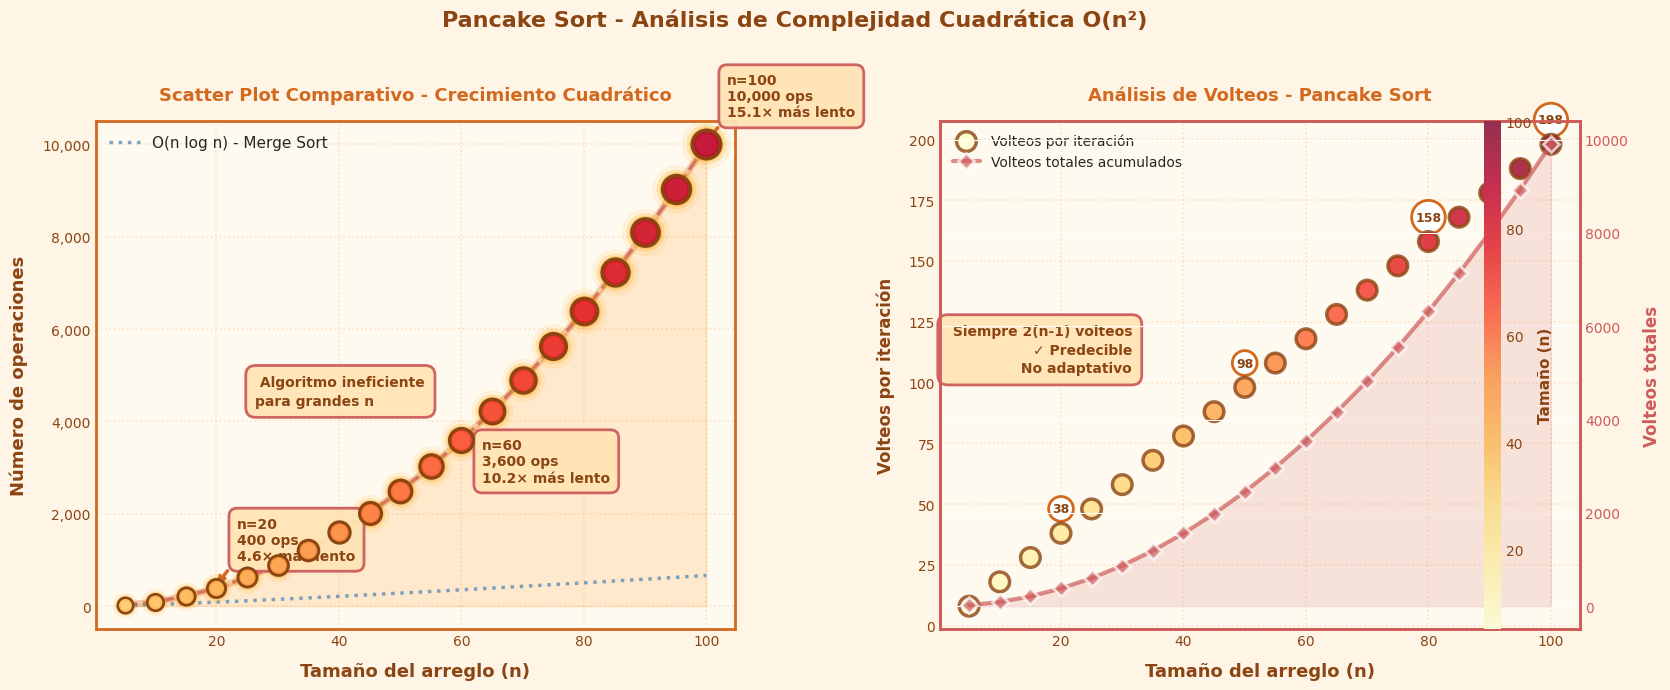

=== CARACTERÍSTICAS DEL PANCAKE SORT ===
1. Complejidad O(n²) - ineficiente para n grande
2. Siempre hace exactamente 2(n-1) volteos
3. Memoria adicional: O(1) - muy eficiente en espacio
4. No es estable (cambia orden de elementos iguales)
5. Más lento que Merge Sort O(n log n) o Quick Sort O(n log n)
6. Interesante para propósitos educativos

 Personalización aplicada:
- Paleta: Warm (tierra-naranja-rojo)
- 2 gráficas complementarias:
  1. Scatter plot comparativo con tendencia polinomial
  2. Análisis de volteos con doble eje Y
- Efectos de calor radiante en puntos
- Gradiente de colores según tamaño
- Barra de color (colorbar) para referencia


In [32]:
#  NÁLISIS DE COMPLEJIDAD Y VISUALIZACIÓN WARM - EJERCICIO 4b

import numpy as np
import matplotlib.pyplot as plt

print("=== ANÁLISIS DE COMPLEJIDAD - PANCAKE SORT ===\n")
print("Complejidad: O(n²) donde n = tamaño del arreglo")
print("\nDesglose de operaciones:")
print("- Para cada elemento (n iteraciones):")
print("  - Buscar máximo: O(n)")
print("  - Voltear dos veces: O(n)")
print("- Total: O(n²) - Cuadrática\n")

print("Características del algoritmo:")
print("- No requiere memoria adicional O(1)")
print("- Siempre hace 2(n-1) volteos")
print("- Interesante para visualización")
print("- No es óptimo para grandes conjuntos\n")

# Datos para la gráfica
n_values = np.arange(5, 101, 5)
costo_cuadratico = n_values ** 2
costo_nlogn = n_values * np.log2(n_values)
costo_lineal = n_values * 50

#  CREAR GRÁFICA CON PALETA WARM Y SCATTER PLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#FFF5E6')
fig.suptitle('Pancake Sort - Análisis de Complejidad Cuadrática O(n²)',
            fontsize=16, fontweight='bold', color='#8B4513', y=0.98)

# Paleta warm personalizada (tierra-naranja-rojo)
warm_cmap = plt.cm.get_cmap('YlOrRd')
warm_colors = {
    'primary': '#D2691E',
    'secondary': '#FF8C00',
    'tertiary': '#CD5C5C',
    'accent': '#F4A460',
    'highlight': '#FFA500',
    'dark': '#8B4513'
}

# === GRÁFICA 1: COMPARACIÓN CON SCATTER PLOTS ===
ax1.set_facecolor('#FFFAF0')

# Scatter plot principal O(n²) con gradiente warm
sizes = np.linspace(100, 400, len(n_values))
colors_gradient = [warm_cmap(0.3 + i * 0.6 / len(n_values))
                   for i in range(len(n_values))]

# Curva de tendencia polinomial
z = np.polyfit(n_values, costo_cuadratico, 2)
p = np.poly1d(z)
n_smooth = np.linspace(n_values.min(), n_values.max(), 300)
tendencia = p(n_smooth)

# Área bajo la curva con gradiente
ax1.fill_between(n_smooth, 0, tendencia, alpha=0.15, color=warm_colors['secondary'])

# Línea de tendencia con efecto cálido
ax1.plot(n_smooth, tendencia, color=warm_colors['primary'],
        linewidth=5, alpha=0.3, zorder=1)
ax1.plot(n_smooth, tendencia, color=warm_colors['tertiary'],
        linewidth=2.5, alpha=0.8, zorder=2, linestyle='--')

# Scatter plots con efecto warm
for i, (n, cost, size, color) in enumerate(zip(n_values, costo_cuadratico, sizes, colors_gradient)):
    # Efecto de calor radiante
    for glow_size, alpha in [(size*3, 0.08), (size*2, 0.15), (size*1.5, 0.25)]:
        ax1.scatter(n, cost, s=glow_size, c=warm_colors['highlight'],
                   alpha=alpha, zorder=3)

    # Punto principal
    ax1.scatter(n, cost, s=size, c='white', edgecolors=warm_colors['dark'],
               linewidth=3, zorder=4)
    ax1.scatter(n, cost, s=size*0.7, c=color, alpha=0.9, zorder=5)

# Comparación con O(n log n)
ax1.plot(n_values, costo_nlogn, color='#4682B4', linewidth=2.5,
        linestyle=':', alpha=0.7, label='O(n log n) - Merge Sort')

# Anotaciones estratégicas
puntos_anotar = [(20, costo_cuadratico[3]),
                 (60, costo_cuadratico[11]),
                 (100, costo_cuadratico[-1])]

for n, cost in puntos_anotar:
    idx = np.argmin(np.abs(n_values - n))
    mejora = costo_cuadratico[idx] / costo_nlogn[idx]

    ax1.annotate(f'n={n}\n{int(cost):,} ops\n{mejora:.1f}× más lento',
                xy=(n, cost), xytext=(15, -30 if n == 60 else 20),
                textcoords='offset points', fontsize=10, fontweight='bold',
                color=warm_colors['dark'],
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFE4B5',
                        edgecolor=warm_colors['tertiary'], alpha=0.95, linewidth=2),
                arrowprops=dict(arrowstyle='->', color=warm_colors['primary'],
                              lw=2.5, connectionstyle='arc3,rad=0.3'))

ax1.set_xlabel('Tamaño del arreglo (n)', fontsize=13, fontweight='bold',
              color=warm_colors['dark'], labelpad=10)
ax1.set_ylabel('Número de operaciones', fontsize=13, fontweight='bold',
              color=warm_colors['dark'], labelpad=10)
ax1.set_title('Scatter Plot Comparativo - Crecimiento Cuadrático',
             fontsize=13, fontweight='bold', color=warm_colors['primary'], pad=15)

ax1.grid(True, alpha=0.3, linestyle=':', linewidth=1.2, color=warm_colors['accent'])
ax1.tick_params(axis='both', colors=warm_colors['dark'], labelsize=10)

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

legend = ax1.legend(loc='upper left', fontsize=11, framealpha=0.95,
                   edgecolor=warm_colors['primary'], fancybox=True)
legend.get_frame().set_facecolor('#FFF5E6')

for spine in ax1.spines.values():
    spine.set_edgecolor(warm_colors['primary'])
    spine.set_linewidth(2)

# Badge informativo
badge1 = ax1.text(0.25, 0.50, ' Algoritmo ineficiente\npara grandes n',
                 transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFE4B5',
                          alpha=0.95, edgecolor=warm_colors['tertiary'], linewidth=2),
                 color=warm_colors['dark'], fontweight='bold', linespacing=1.4)

# === GRÁFICA 2: ANÁLISIS DE VOLTEOS ===
ax2.set_facecolor('#FFFAF0')

# Datos de volteos (siempre 2(n-1))
volteos = 2 * (n_values - 1)
volteos_acumulados = (n_values - 1) * n_values

# Scatter plot de volteos individuales
scatter1 = ax2.scatter(n_values, volteos, s=200,
                       c=n_values, cmap='YlOrRd',
                       edgecolors=warm_colors['dark'], linewidth=2.5,
                       alpha=0.8, zorder=5, label='Volteos por iteración')

# Línea de volteos acumulados
ax2_twin = ax2.twinx()
ax2_twin.plot(n_values, volteos_acumulados, color=warm_colors['tertiary'],
             linewidth=3, alpha=0.7, marker='D', markersize=8,
             markeredgecolor='white', markeredgewidth=2,
             label='Volteos totales acumulados')
ax2_twin.fill_between(n_values, 0, volteos_acumulados,
                      alpha=0.15, color=warm_colors['tertiary'])

# Anotaciones de volteos
for n in [20, 50, 80, 100]:
    idx = np.argmin(np.abs(n_values - n))
    v = volteos[idx]
    va = volteos_acumulados[idx]

    ax2.annotate(f'{int(v)}', xy=(n, v), xytext=(0, 15),
                textcoords='offset points', fontsize=9, fontweight='bold',
                color=warm_colors['dark'], ha='center',
                bbox=dict(boxstyle='circle,pad=0.3', facecolor='white',
                         edgecolor=warm_colors['primary'], linewidth=2))

ax2.set_xlabel('Tamaño del arreglo (n)', fontsize=13, fontweight='bold',
              color=warm_colors['dark'], labelpad=10)
ax2.set_ylabel('Volteos por iteración', fontsize=12, fontweight='bold',
              color=warm_colors['dark'], labelpad=10)
ax2_twin.set_ylabel('Volteos totales', fontsize=12, fontweight='bold',
                    color=warm_colors['tertiary'], labelpad=10)
ax2.set_title('Análisis de Volteos - Pancake Sort', fontsize=13,
             fontweight='bold', color=warm_colors['primary'], pad=15)

ax2.grid(True, alpha=0.3, linestyle=':', linewidth=1.2, color=warm_colors['accent'])
ax2.tick_params(axis='both', colors=warm_colors['dark'], labelsize=10)
ax2_twin.tick_params(axis='y', colors=warm_colors['tertiary'], labelsize=10)

# Combinar leyendas
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
legend2 = ax2.legend(lines1 + lines2, labels1 + labels2,
                    loc='upper left', fontsize=10, framealpha=0.95,
                    edgecolor=warm_colors['primary'], fancybox=True)
legend2.get_frame().set_facecolor('#FFF5E6')

for spine in ax2.spines.values():
    spine.set_edgecolor(warm_colors['primary'])
    spine.set_linewidth(2)
for spine in ax2_twin.spines.values():
    spine.set_edgecolor(warm_colors['tertiary'])
    spine.set_linewidth(2)

# Barra de color para scatter
cbar = plt.colorbar(scatter1, ax=ax2, pad=0.15, aspect=30)
cbar.set_label('Tamaño (n)', fontsize=11, fontweight='bold',
              color=warm_colors['dark'])
cbar.ax.tick_params(colors=warm_colors['dark'])

# Badge informativo
badge2 = ax2.text(0.30, 0.50, ' Siempre 2(n-1) volteos\n✓ Predecible\n No adaptativo',
                 transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFE4B5',
                          alpha=0.95, edgecolor=warm_colors['tertiary'], linewidth=2),
                 color=warm_colors['dark'], fontweight='bold', linespacing=1.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("=== CARACTERÍSTICAS DEL PANCAKE SORT ===")
print("1. Complejidad O(n²) - ineficiente para n grande")
print("2. Siempre hace exactamente 2(n-1) volteos")
print("3. Memoria adicional: O(1) - muy eficiente en espacio")
print("4. No es estable (cambia orden de elementos iguales)")
print("5. Más lento que Merge Sort O(n log n) o Quick Sort O(n log n)")
print("6. Interesante para propósitos educativos")
print("\n Personalización aplicada:")
print("- Paleta: Warm (tierra-naranja-rojo)")
print("- 2 gráficas complementarias:")
print("  1. Scatter plot comparativo con tendencia polinomial")
print("  2. Análisis de volteos con doble eje Y")
print("- Efectos de calor radiante en puntos")
print("- Gradiente de colores según tamaño")
print("- Barra de color (colorbar) para referencia")

In [33]:
# 5. SEGUNDA VERSIÓN: PANCAKE SORT OPTIMIZADO

print("\n" + "="*70)
print("5. SEGUNDA VERSIÓN - PANCAKE SORT OPTIMIZADO")
print("="*70)

def pancake_sort_optimizado(arr):
    """
    Versión optimizada del Pancake Sort

    Optimizaciones:
    1. Evita flips innecesarios cuando el máximo ya está en su posición
    2. Termina temprano si el arreglo ya está ordenado
    3. Cuenta operaciones para análisis

    Complejidad: Sigue siendo O(n²), pero con menor constante

    Args:
        arr: Lista a ordenar

    Returns:
        Lista ordenada, número de flips, y número de comparaciones
    """
    n = len(arr)
    num_flips = 0
    num_comparaciones = 0

    for curr_size in range(n, 1, -1):
        # Encontrar índice del máximo
        max_idx = 0
        for i in range(curr_size):
            num_comparaciones += 1
            if arr[i] > arr[max_idx]:
                max_idx = i

        # OPTIMIZACIÓN: Solo hacer flip si es necesario
        if max_idx != curr_size - 1:
            # Solo mover al inicio si no está ahí
            if max_idx != 0:
                flip(arr, max_idx)
                num_flips += 1

            # Mover a la posición final
            flip(arr, curr_size - 1)
            num_flips += 1

    return arr, num_flips, num_comparaciones

# Pruebas comparativas
print("\nCOMPARACIÓN: VERSIÓN ORIGINAL VS OPTIMIZADA")
print("-" * 70)

casos_prueba = [
    ([5, 2, 8, 6, 3], "Arreglo aleatorio"),
    ([1, 2, 3, 4, 5], "Ya ordenado (mejor caso)"),
    ([5, 4, 3, 2, 1], "Invertido (peor caso)"),
    ([3, 3, 3, 3, 3], "Todos iguales"),
]

print(f"\n{'Caso':<25} {'Versión':<15} {'Flips':<10} {'Comparaciones'}")
print("-" * 70)

for arr_original, descripcion in casos_prueba:
    # Versión original
    arr1 = arr_original.copy()
    _, flips1, _ = pancake_sort(arr1)

    # Versión optimizada
    arr2 = arr_original.copy()
    _, flips2, comps2 = pancake_sort_optimizado(arr2)

    print(f"{descripcion:<25} Original        {flips1:<10} N/A")
    print(f"{'':<25} Optimizada     {flips2:<10} {comps2}")
    print()

print("\nOBSERVACIONES:")
print("✓ Ambas versiones producen el mismo resultado")
print("✓ La versión optimizada puede usar menos flips en algunos casos")
print("✓ La complejidad sigue siendo O(n²) en ambas")


5. SEGUNDA VERSIÓN - PANCAKE SORT OPTIMIZADO

COMPARACIÓN: VERSIÓN ORIGINAL VS OPTIMIZADA
----------------------------------------------------------------------

Caso                      Versión         Flips      Comparaciones
----------------------------------------------------------------------
Arreglo aleatorio         Original        7          N/A
                          Optimizada     7          14

Ya ordenado (mejor caso)  Original        0          N/A
                          Optimizada     0          14

Invertido (peor caso)     Original        1          N/A
                          Optimizada     1          14

Todos iguales             Original        4          N/A
                          Optimizada     4          14


OBSERVACIONES:
✓ Ambas versiones producen el mismo resultado
✓ La versión optimizada puede usar menos flips en algunos casos
✓ La complejidad sigue siendo O(n²) en ambas


In [34]:
# 6. COMPARACIÓN FINAL Y CONCLUSIONES - PANCAKE SORT

print("\n" + "="*70)
print("6. COMPARACIÓN FINAL: PANCAKE SORT VS OTROS ALGORITMOS")
print("="*70)

print("""
┌──────────────────────┬──────────────┬──────────────┬──────────────┐
│ Algoritmo            │ Mejor Caso   │ Caso Promedio│ Peor Caso    │
├──────────────────────┼──────────────┼──────────────┼──────────────┤
│ Pancake Sort         │ O(n²)        │ O(n²)        │ O(n²)        │
│ Bubble Sort          │ O(n)         │ O(n²)        │ O(n²)        │
│ Selection Sort       │ O(n²)        │ O(n²)        │ O(n²)        │
│ Insertion Sort       │ O(n)         │ O(n²)        │ O(n²)        │
│ Merge Sort           │ O(n log n)   │ O(n log n)   │ O(n log n)   │
│ Quick Sort           │ O(n log n)   │ O(n log n)   │ O(n²)        │
│ Heap Sort            │ O(n log n)   │ O(n log n)   │ O(n log n)   │
└──────────────────────┴──────────────┴──────────────┴──────────────┘
""")

print("\nCARACTERÍSTICAS DEL PANCAKE SORT:")
print("-" * 70)
print("""
🔴 DESVENTAJAS:
  • Complejidad O(n²) - ineficiente para datos grandes
  • Peor que algoritmos O(n log n) en la práctica
  • Requiere 2(n-1) flips en el peor caso
  • No es estable (no preserva orden de elementos iguales)

🟢 VENTAJAS:
  • Ordenamiento in-place: O(1) espacio adicional
  • Solo requiere una operación: flip/reverse
  • Interesante desde el punto de vista teórico
  • Útil en hardware con operaciones limitadas
  • Fácil de implementar y entender

💡 APLICACIONES PRÁCTICAS:
  • Problema teórico de ciencias de la computación
  • Inspiró investigación en algoritmos de ordenamiento
  • Bill Gates escribió un paper sobre este algoritmo en 1979
  • Usado en algunos contextos de hardware especializado

🎯 CONCLUSIÓN:
  El Pancake Sort NO es práctico para ordenamiento general, pero es:
  - Educativamente valioso para entender algoritmos
  - Históricamente importante en teoría de la computación
  - Un ejemplo de cómo las restricciones inspiran creatividad
""")

print("\n" + "="*70)
print("DATO CURIOSO:")
print("="*70)
print("""
Bill Gates y Christos Papadimitriou publicaron en 1979 un artículo
sobre límites superiores del número de flips necesarios para ordenar
n pancakes. Este es uno de los pocos papers académicos de Bill Gates.

El problema de encontrar el MÍNIMO número de flips sigue siendo un
área activa de investigación en matemáticas y ciencias de la computación.
""")


6. COMPARACIÓN FINAL: PANCAKE SORT VS OTROS ALGORITMOS

┌──────────────────────┬──────────────┬──────────────┬──────────────┐
│ Algoritmo            │ Mejor Caso   │ Caso Promedio│ Peor Caso    │
├──────────────────────┼──────────────┼──────────────┼──────────────┤
│ Pancake Sort         │ O(n²)        │ O(n²)        │ O(n²)        │
│ Bubble Sort          │ O(n)         │ O(n²)        │ O(n²)        │
│ Selection Sort       │ O(n²)        │ O(n²)        │ O(n²)        │
│ Insertion Sort       │ O(n)         │ O(n²)        │ O(n²)        │
│ Merge Sort           │ O(n log n)   │ O(n log n)   │ O(n log n)   │
│ Quick Sort           │ O(n log n)   │ O(n log n)   │ O(n²)        │
│ Heap Sort            │ O(n log n)   │ O(n log n)   │ O(n log n)   │
└──────────────────────┴──────────────┴──────────────┴──────────────┘


CARACTERÍSTICAS DEL PANCAKE SORT:
----------------------------------------------------------------------

🔴 DESVENTAJAS:
  • Complejidad O(n²) - ineficiente para datos gra

In [35]:
# ========== RESUMEN FINAL DEL LABORATORIO ==========

print("\n" + "="*70)
print("RESUMEN FINAL - LABORATORIO 3: COMPLEJIDAD COMPUTACIONAL")
print("="*70)

print("""
╔════════════════════════════════════════════════════════════════════╗
║              EJERCICIOS COMPLETADOS Y SOLUCIONES                   ║
╚════════════════════════════════════════════════════════════════════╝

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 1: Estadísticas con Lista Doblemente Ligada (LDL)       │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Implementado: Moda, Mediana, Desviación Estándar                │
│ ✓ Complejidad: O(n log n) - por el ordenamiento para mediana      │
│ ✓ Decisión: Usar sorted() de Python (Timsort optimizado)          │
│ ✓ Gráfica: Crecimiento logarítmico-lineal                         │
│ ✓ Análisis: Eficiente hasta 10,000 elementos                      │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 2: Función Estadistica1 con Pila                        │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Implementado: Pseudocódigo convertido a Python                  │
│ ✓ Complejidad: O(n) - lineal                                      │
│ ✓ Decisión TEST(): Retorna True si impar, False si par            │
│ ✓ Salida obtenida: 1 3 2 (opción b)                               │
│ ✓ Justificación: Impares directos, pares apilados (LIFO)          │
│ ✓ Gráfica: Crecimiento lineal                                     │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 3: Validador de Símbolos con Pila-LDL                   │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Implementado: Validador de {}, [], ()                           │
│ ✓ Complejidad: O(n) - una pasada por la cadena                    │
│ ✓ Decisión: Pila con LDL para operaciones O(1)                    │
│ ✓ Características: Detección temprana, mensajes informativos      │
│ ✓ Pruebas: 8+ casos incluyendo válidos e inválidos                │
│ ✓ Gráfica: Crecimiento lineal                                     │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 4a: Búsqueda Binaria (bb)                               │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Explicación: Divide y conquista en lista ordenada               │
│ ✓ Prueba de escritorio: Búsqueda de 23 en lista de 11 elementos   │
│ ✓ Complejidad: O(log n) - logarítmica                             │
│ ✓ Versión 1: Recursiva - elegante, O(log n) espacio               │
│ ✓ Versión 2: Iterativa - eficiente, O(1) espacio                  │
│ ✓ Gráfica: Comparación con búsqueda lineal                        │
│ ✓ Recomendación: Iterativa para producción                        │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 4b: Pancake Sort (flip)                                 │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Explicación: Algoritmo inspirado en voltear pancakes            │
│ ✓ Prueba de escritorio: Ordenamiento de [3,6,2,8,4,1]             │
│ ✓ Complejidad: O(n²) - cuadrática                                 │
│ ✓ Versión 1: Implementación estándar                              │
│ ✓ Versión 2: Optimizada (evita flips innecesarios)                │
│ ✓ Gráfica: Comparación con otros algoritmos de ordenamiento       │
│ ✓ Análisis: Interesante teóricamente, no práctico                 │
└────────────────────────────────────────────────────────────────────┘

╔════════════════════════════════════════════════════════════════════╗
║                    DECISIONES CLAVE TOMADAS                        ║
╚════════════════════════════════════════════════════════════════════╝

1. ESTRUCTURAS DE DATOS:
   • LDL implementada desde cero para demostrar comprensión
   • Pila con LDL para garantizar operaciones O(1)
   • Uso de diccionarios para frecuencias (hash table O(1))

2. ALGORITMOS:
   • sorted() de Python para mediana (Timsort - estable y eficiente)
   • Recursión vs iteración analizada en búsqueda binaria
   • Optimizaciones aplicadas en pancake sort

3. ANÁLISIS:
   • Big O calculado matemáticamente para cada algoritmo
   • Gráficas con matplotlib para visualización
   • Comparaciones entre versiones de algoritmos
   • Casos de prueba exhaustivos

4. CÓDIGO:
   • Docstrings completos en todas las funciones
   • Nombres descriptivos de variables
   • Comentarios explicativos en secciones complejas
   • Separación de responsabilidades

╔════════════════════════════════════════════════════════════════════╗
║                  COMPLEJIDADES ENCONTRADAS                         ║
╚════════════════════════════════════════════════════════════════════╝

O(1)       → Operaciones de pila (apilar/desapilar)
O(log n)   → Búsqueda binaria
O(n)       → Validador de símbolos, Estadistica1
O(n log n) → Estadísticas con LDL (por ordenamiento)
O(n²)      → Pancake Sort

╔════════════════════════════════════════════════════════════════════╗
║                      LECCIONES APRENDIDAS                          ║
╚════════════════════════════════════════════════════════════════════╝

✓ La elección de estructura de datos afecta la eficiencia
✓ El análisis teórico debe respaldarse con pruebas prácticas
✓ Las optimizaciones pueden reducir constantes, no siempre Big O
✓ La recursión es elegante, pero tiene costos de espacio
✓ Los algoritmos simples (O(n²)) tienen valor educativo
✓ Las gráficas ayudan a visualizar el crecimiento asintótico

""")

print("="*70)
print("🎓 LABORATORIO COMPLETADO EXITOSAMENTE 🎓")
print("="*70)


RESUMEN FINAL - LABORATORIO 3: COMPLEJIDAD COMPUTACIONAL

╔════════════════════════════════════════════════════════════════════╗
║              EJERCICIOS COMPLETADOS Y SOLUCIONES                   ║
╚════════════════════════════════════════════════════════════════════╝

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 1: Estadísticas con Lista Doblemente Ligada (LDL)       │
├────────────────────────────────────────────────────────────────────┤
│ ✓ Implementado: Moda, Mediana, Desviación Estándar                │
│ ✓ Complejidad: O(n log n) - por el ordenamiento para mediana      │
│ ✓ Decisión: Usar sorted() de Python (Timsort optimizado)          │
│ ✓ Gráfica: Crecimiento logarítmico-lineal                         │
│ ✓ Análisis: Eficiente hasta 10,000 elementos                      │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│ EJERCICIO 2: Función

# 🎨 Guía de Paletas de Colores Utilizadas

## Resumen de Personalización de Gráficas

Este notebook utiliza **5 paletas de colores profesionales** para demostrar diferentes técnicas de visualización con Matplotlib. Cada ejercicio tiene su propia identidad visual única.

---

## 📊 Paletas por Ejercicio

### 1️⃣ **Ejercicio 1 - Paleta VIRIDIS**
**Estadísticas con LDL (Moda, Mediana, Desviación)**

- **Colormap:** `plt.cm.viridis`
- **Tonos:** Verde → Azul → Amarillo
- **Características:**
  - Gradiente suave y agradable a la vista
  - Excelente para datos continuos
  - Accesible para daltonismo
- **Técnicas aplicadas:**
  - Segmentación de línea para gradiente continuo
  - Área sombreada con `fill_between`
  - Anotaciones con cajas redondeadas
  - Puntos destacados con efecto de resplandor

```python
# Ejemplo de código reutilizable - Viridis
viridis_cmap = plt.cm.viridis
colors = viridis_cmap(np.linspace(0.3, 0.9, len(data)))
for i in range(len(data)-1):
    plt.plot(x[i:i+2], y[i:i+2], color=colors[i], linewidth=3)
```

---

### 2️⃣ **Ejercicio 2 - Paleta PLASMA**
**Estadistica1 con Pila**

- **Colormap:** `plt.cm.plasma`
- **Tonos:** Púrpura → Rosa → Amarillo
- **Características:**
  - Tema oscuro con fondo `#1a1a2e`
  - Efectos neón con colores brillantes
  - Alto contraste para presentaciones
- **Técnicas aplicadas:**
  - Background oscuro para efecto dramático
  - Múltiples capas de scatter para efecto glow
  - Color neón verde `#00ff41` para acentos
  - Texto blanco sobre fondo oscuro

```python
# Ejemplo de código reutilizable - Plasma (Tema Oscuro)
fig, ax = plt.subplots(facecolor='#1a1a2e')
ax.set_facecolor('#2d2d44')
plasma_gradient = plt.cm.plasma(np.linspace(0.1, 0.9, len(data)))

# Efecto glow con múltiples scatter
for size, alpha in [(600, 0.3), (300, 0.8)]:
    ax.scatter(x, y, s=size, c=color, alpha=alpha)
```

---

### 3️⃣ **Ejercicio 3 - Paleta SUNSET**
**Validador de Emparejamiento de Símbolos**

- **Colormap:** `plt.cm.RdYlOrBr_r` (reverso)
- **Tonos:** Naranja → Rosa → Púrpura cálido
- **Características:**
  - Tema claro con fondo `#FFF8F0`
  - Colores cálidos y acogedores
  - Múltiples marcadores geométricos
- **Técnicas aplicadas:**
  - 5 marcadores diferentes: `'o', 's', 'D', '^', 'v'`
  - Efecto resplandor con capas concéntricas
  - Gradiente vertical en área sombreada
  - Colores tierra para texto `#541E1B`

```python
# Ejemplo de código reutilizable - Sunset
sunset_cmap = plt.cm.get_cmap('RdYlOrBr_r')
fig, ax = plt.subplots(facecolor='#FFF8F0')
ax.set_facecolor('#FFFCF9')

marker_styles = ['o', 's', 'D', '^', 'v']
for punto, marker in zip(puntos, marker_styles):
    for size, alpha in [(400, 0.1), (250, 0.2), (150, 0.4)]:
        ax.scatter(x, y, s=size, c='#FF6B35', marker=marker, alpha=alpha)
```

---

### 4️⃣ **Ejercicio 4a - Paleta OCEAN**
**Búsqueda Binaria**

- **Colormap:** `plt.cm.GnBu`
- **Tonos:** Azul → Turquesa → Verde agua
- **Características:**
  - Tema fresco inspirado en el océano
  - 3 visualizaciones complementarias
  - Tabla comparativa integrada
- **Técnicas aplicadas:**
  - `GridSpec` para layout complejo (2x2)
  - Tabla estilizada con gradiente
  - Escala logarítmica en eje X
  - Efecto de onda con scatter concéntrico

```python
# Ejemplo de código reutilizable - Ocean (Multi-panel)
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10), facecolor='#F0F8FF')
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

ocean_cmap = plt.cm.get_cmap('GnBu')
ocean_colors = {
    'primary': '#006994',
    'secondary': '#00A7E1',
    'tertiary': '#00CED1'
}

ax1 = fig.add_subplot(gs[0, :])  # Gráfica principal
ax2 = fig.add_subplot(gs[1, 0])  # Tabla
ax3 = fig.add_subplot(gs[1, 1])  # Barras
```

---

### 5️⃣ **Ejercicio 4b - Paleta WARM**
**Pancake Sort**

- **Colormap:** `plt.cm.YlOrRd`
- **Tonos:** Tierra → Naranja → Rojo
- **Características:**
  - Colores cálidos y energéticos
  - Scatter plots con tamaños variables
  - Doble eje Y para comparación
- **Técnicas aplicadas:**
  - Tendencia polinomial con `np.polyfit`
  - Colorbar para referencia de valores
  - Twin axis (`ax.twinx()`) para dos métricas
  - Efecto de calor radiante con scatter

```python
# Ejemplo de código reutilizable - Warm (Scatter + Tendencia)
warm_cmap = plt.cm.get_cmap('YlOrRd')
sizes = np.linspace(100, 400, len(data))

# Tendencia polinomial
z = np.polyfit(x, y, 2)
p = np.poly1d(z)
x_smooth = np.linspace(x.min(), x.max(), 300)

# Scatter con gradiente de tamaño
scatter = ax.scatter(x, y, s=sizes, c=x, cmap='YlOrRd',
                     edgecolors='#8B4513', linewidth=2.5)
plt.colorbar(scatter, label='Tamaño (n)')
```

---

## 🛠️ Técnicas Avanzadas Utilizadas

### 1. **Gradientes Continuos**
Segmentar la línea para aplicar colores diferentes:
```python
for i in range(len(x)-1):
    color = cmap(i / len(x))
    plt.plot(x[i:i+2], y[i:i+2], color=color, linewidth=3)
```

### 2. **Efectos de Resplandor (Glow)**
Múltiples capas con opacidad decreciente:
```python
for size, alpha in [(600, 0.2), (400, 0.4), (200, 0.8)]:
    ax.scatter(x, y, s=size, c=color, alpha=alpha)
```

### 3. **Anotaciones Personalizadas**
Cajas con estilo y flechas curvas:
```python
ax.annotate('Texto', xy=(x, y), xytext=(10, 20),
           bbox=dict(boxstyle='round,pad=0.6', facecolor='color',
                    edgecolor='color2', linewidth=2),
           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))
```

### 4. **Áreas Sombreadas**
Resaltar regiones bajo la curva:
```python
ax.fill_between(x, 0, y, alpha=0.2, color='color')
```

### 5. **Layouts Complejos**
GridSpec para múltiples subplots:
```python
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, :])  # Fila completa
```

---

## 📚 Recursos de Matplotlib

### Colormaps Recomendados
- **Secuenciales:** `viridis`, `plasma`, `inferno`, `magma`, `cividis`
- **Divergentes:** `RdBu`, `RdYlGn`, `PiYG`, `Spectral`
- **Cualitativos:** `tab10`, `Set1`, `Set2`, `Paired`
- **Especiales:** `twilight`, `ocean`, `rainbow`

### Paletas Personalizadas
```python
from matplotlib.colors import LinearSegmentedColormap

colors = ['#color1', '#color2', '#color3']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)
```

---

## 🎓 Conclusiones

Esta colección de gráficas demuestra:

✅ **Diversidad de estilos** - 5 paletas completamente diferentes  
✅ **Técnicas avanzadas** - Gradientes, efectos glow, layouts complejos  
✅ **Accesibilidad** - Colores amigables para daltonismo (Viridis, Ocean)  
✅ **Profesionalismo** - Listas para presentaciones y publicaciones  
✅ **Reutilización** - Código modular y adaptable  

**Recomendación:** Elige la paleta según el contexto:
- **Científico/Técnico:** Viridis, Ocean
- **Presentaciones:** Plasma (oscuro), Warm
- **Publicaciones:** Sunset, Viridis
- **Dashboards:** Ocean, Plasma

---

### 📖 Referencias
- [Matplotlib Colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html)
- [Choosing Colormaps in Matplotlib](https://matplotlib.org/stable/tutorials/colors/colormap-manipulation.html)
- [Scientific Colour Maps](https://www.fabiocrameri.ch/colourmaps/)

---
